# Recyclage et déplacements : à la recherche d'un profil écologique géographique ?
Analyse croisée de la valorisation des déchets et des modes de transport (2016-2022)

## Problématique

Les questions écologiques constituent une thématique importante notamment dans la gestion des territoires. Partant de ce constat, nous avons cherché un indicateur de comportement écologique que l'on pourrait croiser avec des données géographiques liés à la population francaise. Nous avons donc décidé de nous interesser à la **valorisation des déchets ménagers et assimilés (DMA)**, et aux **modes de déplacement**.

Nous allons montrer que tant la valorisation que les modes de transport varient considérablement d'un département à l'autre, et nous présenterons quelques facteurs territoriaux et socio-économiques expliquant ces disparités.

Nous cherchons à identifier si certains départements se distinguent par un "profil écologique complet" :

Côté Déchets : Quels départements valorisent le mieux leurs déchets ménagers (Recyclage & Compostage) ? Est-ce lié à la richesse ou à la ruralité ?

Ce notebook explore deux hypothèses principales :
1. **Hypothèse territoriale** : les départements ruraux, bénéficiant d'une gestion différente des déchets (compostage, valorisation organique), présenteraient de meilleurs taux de valorisation.
2. **Hypothèse socio-économique** : les départements plus aisés investiraient davantage dans les infrastructures de tri et de recyclage.

Nous nous sommes aussi intéressés aux deux composantes de la valorisation :
- **Valorisation de la matière** : recyclage
- **Valorisation organique** : compostage et méthanisation

Côté Mobilité : Comment l'usage du vélo et des transports en commun a-t-il évolué entre 2016 et 2022 ?
Comprendre comment les **modes de transport** utilisés pour aller travailler ont évolué entre **2016 et 2022** en France métropolitaine, à l'échelle des départements.

Synthèse : Existe-t-il une corrélation entre les zones qui recyclent le plus et celles qui utilisent le moins la voiture ?

## Données utilisées

| Source | Fichier | Description |
|--------|---------|-------------|
| ADEME / SINOE | `SINOE04_DestinationDmaParTypeTraitement.csv` | Tonnages de déchets par type de traitement et département |
| INSEE | `DS_RP_NAVETTES_PRINC_2022_data.csv` | Déplacements domicile-travail selon le mode de transport, source **Recensement de la Population** (RP) de l'INSEE, disponibles sur data.gouv.fr.
| INSEE | `FET2021-19.xlsx` | Grille de densité communale (urbain/rural) |
| INSEE | `niv2021.xlsx` | Niveau de vie médian annuel par département(légèrement revu, les 3 premiers lignes ont été supprimées |

> **Reproductibilité** : les fichiers de données doivent être placés dans le même répertoire que ce notebook. Les sources sont disponibles sur [data.ademe.fr](https://data.ademe.fr) et [insee.fr](https://insee.fr).

## Plan

0. **Packages et imports**
1. **Chargement et nettoyage des données**
2. **Analyse descriptive**
    * **I. Volet Déchets :** Taux de valorisation matière vs valorisation organique
        * *Tests d'Hypothèses :*
            * **Hypothèse 1 (Territoriale) :** La ruralité favorise-t-elle le compostage ?
            * **Hypothèse 2 (Socio-économique) :** Le niveau de vie influence-t-il le taux de recyclage ?
    * **II. Volet Mobilité :** Évolution des Navettes (2016-2022)
        * **Focus 2016 vs 2022 :** Top 5 des départements cyclistes et utilisateurs de transports en commun.
        * **Analyse de changement :** Quels départements ont connu la plus forte progression du vélo depuis 2016 ?
3. **Visualisations :** distributions, nuages de points, cartes
4. **Modélisation :** corrélations et régression multiple
5. **Conclusion :** Synthèse des disparités territoriales et validation/infirmation des hypothèses de départ

## 0. Quelques package necessaires : 

Installer les packages avec le fichier requirement 

In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# ── Imports ────────────────────────────────────────────────────────────────────
# Standard & Data
import pandas as pd
# import numpy as np
import requests
import zipfile
from io import StringIO, BytesIO

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
# from matplotlib.colors import ListedColormap

# Cartographie & Géo
import geopandas as gpd

# Stats & Machine Learning
# import statsmodels.api as sm
# from scipy.stats import pearsonr, spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Fonctions personnalisées (locales)
from fonctions import (
    scatter_regression, 
    attribuer_profil, 
    afficher_correlations, 
    regression_ols, 
    diagnostics_ols
)

# ── Paramètres globaux ─────────────────────────────────────────────────────────
# Résolution des figures (plus net)
plt.rcParams["figure.dpi"] = 120

# Style Seaborn : fond blanc avec grille légère, couleurs douces
sns.set_theme(style="whitegrid", palette="muted")

# Formatage des nombres : pas de notation scientifique, 2 décimales
pd.options.display.float_format = '{:.2f}'.format

# URL du fond de carte GeoJSON (96 départements métropolitains)
GEOJSON_URL = "https://france-geojson.gregoiredavid.fr/repo/departements.geojson"

print("Imports et paramètres globaux OK")

Imports et paramètres globaux OK


## 1. Chargement et nettoyage des données

### RECUPERATIONS DES DONNEES AVEC LES API

In [3]:
# Récupération des données ADEME (URL direct)
# URL directe du fichier CSV ADEME sur data.ademe.fr
ADEME_CSV_URL = (
    "https://data.ademe.fr/data-fair/api/v1/datasets/"
    "sinoe-(r)-destination-des-dma-collectes-par-type-de-traitement/"
    "data-files/SINOE04_DestinationDmaParTypeTraitement.csv"
)
response = requests.get(ADEME_CSV_URL)
response.raise_for_status()
# StringIO permet de lire le texte téléchargé comme si c'était un fichier
# sep=None + engine='python' : détection automatique du séparateur
df = pd.read_csv(StringIO(response.text), sep=None, engine="python")
print(f"Fichier ADEME chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes")

df_ademe = df.copy()
df_ademe.head()

Fichier ADEME chargé : 14660 lignes × 10 colonnes


,ANNEE,C_REGION,L_REGION,C_DEPT,N_DEPT,C_TYP_REG_DECHET,L_TYP_REG_DECHET,C_TYP_REG_SERVICE,L_TYP_REG_SERVICE,TONNAGE_DMA
0,2009,84,Auvergne-Rhône-Alpes,01,Ain,07A,Ordures ménagères résiduelles,02B,Incinération avec récupération d'énergie,"98575,13"
1,2009,84,Auvergne-Rhône-Alpes,01,Ain,07A,Ordures ménagères résiduelles,02D,Stockage,"35633,56"
2,2009,84,Auvergne-Rhône-Alpes,01,Ain,07E,Matériaux recyclables,02A,Valorisation matière,"61734,13"
3,2009,84,Auvergne-Rhône-Alpes,01,Ain,07E,Matériaux recyclables,02E,Valorisation organique,"5460,17"
4,2009,84,Auvergne-Rhône-Alpes,01,Ain,07E,Matériaux recyclables,02B,Incinération avec récupération d'énergie,"831,58"


Import de la base de données avec les déplacements domicile - travail sur le site data.gouv.fr
https://www.data.gouv.fr/datasets/deplacements-domicile-travail

In [4]:
# Utilisation de l'API pour recuperer les données des déplacements

url = "https://api.insee.fr/melodi/data/DS_RP_NAVETTES_PRINC"

r = requests.get(url)
data = r.json()

obs = data["observations"]

df = pd.json_normalize(obs)
df = df.rename(columns={
    "dimensions.GEO":"GEO",
    "dimensions.WORK_AREA":"WORK_AREA",
    "dimensions.FREQ":"FREQ",
    "dimensions.EMPSTA_ENQ":"EMPSTA_ENQ",
    "dimensions.TIME_PERIOD":"YEAR",
    "dimensions.RP_MEASURE":"MEASURE",
    "dimensions.TRANS":"TRANS",
    "dimensions.AGE":"AGE",
    "measures.OBS_VALUE_NIVEAU.value":"VALUE"
})

df_transport= df.copy()
print(df_transport.head(5))


                   GEO WORK_AREA FREQ EMPSTA_ENQ  YEAR MEASURE TRANS     AGE  \
0  2025-EPCI-200043396        10    A          1  2022     POP    _T  Y_GE15   
1  2025-EPCI-245700398        _T    A          1  2022     POP     5  Y_GE15   
2  2025-EPCI-244100798        _T    A          1  2022     POP     6  Y_GE15   
3  2025-EPCI-240200469        _T    A          1  2022     POP     6  Y_GE15   
4  2025-EPCI-246800445        _T    A          1  2022     POP     5  Y_GE15   

     VALUE  
0 10296.12  
1  9307.98  
2   163.20  
3    68.25  
4  6355.04  


Avec une limitation de 10 000 lignes par page de l'API nous ne pouvons pas recuperer toutes les données par consequent nous utilisons l'approche avec le fichier ZIP.
On télécharge directement le fichier complet depuis data.gouv.fr. Le fichier CSV est extrait en mémoire vive (sans écriture sur disque) grâce à `BytesIO`.

In [9]:

url = "https://www.data.gouv.fr/api/1/datasets/r/b35881a9-da09-49bf-a80e-8fa17651e927"

try:
    # 1. On télécharge le ZIP contenant les données et les metadonnées
    response = requests.get(url)
    
    # 2. On ouvre l'archive en mémoire
    with zipfile.ZipFile(BytesIO(response.content)) as z:
        # 3. On ouvre spécifiquement le fichier contenant les données
        with z.open('DS_RP_NAVETTES_PRINC_2022_data.csv') as f:
            df_transport = pd.read_csv(f, sep=';', encoding='latin-1', low_memory=False)
            
    print(f"Importation réussie ! {len(df_transport)} lignes chargées.")
    print(df_transport.head())

except Exception as e:
    print(f"Erreur : {e}")

Importation réussie ! 1191432 lignes chargées.
      AGE  EMPSTA_ENQ FREQ        GEO GEO_OBJECT RP_MEASURE TRANS WORK_AREA  \
0  Y_GE15           1    A          F     FRANCE        POP     2        _T   
1  Y_GE15           1    A  249710047       EPCI        POP    _T        10   
2  Y_GE15           1    A  249710047       EPCI        POP     6        _T   
3  Y_GE15           1    A          F     FRANCE        POP     1        _T   
4  Y_GE15           1    A         FM     FRANCE        POP    _T        23   

   TIME_PERIOD  OBS_VALUE  
0         2022 1729514.24  
1         2022    2045.00  
2         2022     131.00  
3         2016 1153683.83  
4         2011  995946.60  


## Découverte et nettoyage des bases de données

Avant toute analyse, nous allons **explorer la structure** du jeu de données : types de variables, valeurs manquantes, modalités disponibles.

### 1.1 Données SINOE (déchets)
 Le fichier SINOE recense les tonnages de DMA par département, par année
 et par **type de traitement**. Les types disponibles sont :
 - Valorisation matière ← recyclage
 - Valorisation organique ← compostage / méthanisation
 - Incinération avec/sans récupération d'énergie
 - Stockage
 - autre


In [6]:
 # Étape 1 : aperçu des données brutes
print(f"Dimensions brutes : {df_ademe.shape}")
print(f"Années disponibles : {sorted(df_ademe['ANNEE'].unique())}")
print(f"Types de traitement : {df_ademe['L_TYP_REG_SERVICE'].unique().tolist()}")


Dimensions brutes : (14660, 10)
Années disponibles : [np.int64(2009), np.int64(2011), np.int64(2013), np.int64(2015), np.int64(2017), np.int64(2019), np.int64(2021)]
Types de traitement : ["Incinération avec récupération d'énergie", 'Stockage', 'Valorisation matière', 'Valorisation organique', 'Non précisé', 'Stockage pour inertes', "Incinération sans récupération d'énergie"]


### Verification de la presence des valeurs manquantes

In [7]:
df_ademe.isna().sum()

ANNEE                0
C_REGION             0
L_REGION             0
C_DEPT               0
N_DEPT               0
C_TYP_REG_DECHET     0
L_TYP_REG_DECHET     0
C_TYP_REG_SERVICE    0
L_TYP_REG_SERVICE    0
TONNAGE_DMA          0
dtype: int64

CONSTAT: PAS DE VALEURS MANQUANTES

In [8]:

    # Étape 2 : nettoyage du tonnage (virgule → point pour Python)
df_ademe["TONNAGE_DMA"] = (
        df_ademe["TONNAGE_DMA"]
        .astype(str)                         
        .str.replace(",", ".", regex=False)  # "98575,13" → "98575.13"
        .astype(float)                       # conversion en nombre décimal
    )


In [9]:
# Étape 3 : codes département sur 2 caractères pour les jointures et renommer la colonne departement
df_ademe["code_dept"] = df_ademe["C_DEPT"].astype(str).str.zfill(2)
df_ademe["departement"] = df_ademe["N_DEPT"]


In [10]:
# Étape 4 : conserver uniquement la dernière année disponible
annee_max = df_ademe["ANNEE"].max()
df_ademe = df_ademe[df_ademe["ANNEE"] == annee_max].copy()
print(f"\nAnnée retenue : {annee_max}  ({len(df)} lignes après filtre)")



Année retenue : 2021  (10000 lignes après filtre)


In [11]:
# Étape 5 : marquage des lignes par type de valorisation
    # Deux colonnes booléennes (True/False) pour distinguer les composantes
df_ademe["est_valo_matiere"] = df_ademe["L_TYP_REG_SERVICE"] == "Valorisation matière"
df_ademe["est_valo_organique"] = df_ademe["L_TYP_REG_SERVICE"] == "Valorisation organique"

# Colonnes de tonnage conditionnelles créées avant le groupby.
# where(condition, 0) : garde le tonnage si la condition est vraie, sinon 0.
df_ademe["tonnage_si_matiere"] = df_ademe["TONNAGE_DMA"].where(df_ademe["est_valo_matiere"], 0)
df_ademe["tonnage_si_organique"] = df_ademe["TONNAGE_DMA"].where(df_ademe["est_valo_organique"], 0)


In [12]:

    # Étape 6 : agrégation par département
dept = (
        df_ademe.groupby(["code_dept", "departement"], as_index=False)
        .agg(
            tonnage_total=("TONNAGE_DMA", "sum"),
            tonnage_valo_matiere=("tonnage_si_matiere", "sum"),
            tonnage_valo_organique=("tonnage_si_organique", "sum"),
        )
    )

In [13]:
# Calcul des taux de valorisation (en %)
    # Taux = tonnage valorisé / tonnage total × 100
dept["tonnage_valo_total"] = dept["tonnage_valo_matiere"] + dept["tonnage_valo_organique"]
dept["taux_valo_total_pct"] = dept["tonnage_valo_total"] / dept["tonnage_total"] * 100
dept["taux_valo_matiere_pct"] = dept["tonnage_valo_matiere"] / dept["tonnage_total"] * 100
dept["taux_valo_organique_pct"] = dept["tonnage_valo_organique"] / dept["tonnage_total"] * 100

print(f"{len(dept)} départements après agrégation")

99 départements après agrégation


In [14]:
# Appel de la fonction charger_sinoe
sinoe_dept = dept.copy()
display(sinoe_dept.head())

,code_dept,departement,tonnage_total,tonnage_valo_matiere,tonnage_valo_organique,tonnage_valo_total,taux_valo_total_pct,taux_valo_matiere_pct,taux_valo_organique_pct
0,01,Ain,383489.91,139897.47,77012.73,216910.20,56.56,36.48,20.08
1,02,Aisne,328139.23,100389.96,40931.54,141321.50,43.07,30.59,12.47
2,03,Allier,211885.62,61220.51,30746.28,91966.79,43.40,28.89,14.51
3,04,Alpes-de-Haute-Provence,136286.08,40255.77,15084.65,55340.42,40.61,29.54,11.07
4,05,Hautes-Alpes,98738.31,37296.24,5164.97,42461.21,43.00,37.77,5.23


### 1.2  Données Insee (déplacements)

In [10]:
print(df_transport.info())
print(df_transport.nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1191432 entries, 0 to 1191431
Data columns (total 10 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   AGE          1191432 non-null  object 
 1   EMPSTA_ENQ   1191432 non-null  int64  
 2   FREQ         1191432 non-null  object 
 3   GEO          1191432 non-null  object 
 4   GEO_OBJECT   1191432 non-null  object 
 5   RP_MEASURE   1191432 non-null  object 
 6   TRANS        1191432 non-null  object 
 7   WORK_AREA    1191432 non-null  object 
 8   TIME_PERIOD  1191432 non-null  int64  
 9   OBS_VALUE    1191432 non-null  float64
dtypes: float64(1), int64(2), object(7)
memory usage: 90.9+ MB
None
AGE                 1
EMPSTA_ENQ          1
FREQ                1
GEO             37894
GEO_OBJECT         11
RP_MEASURE          1
TRANS               8
WORK_AREA           7
TIME_PERIOD         3
OBS_VALUE      804699
dtype: int64


### Nettoyage : suppression des colonnes inutiles et filtrage

On simplifie la base en :
- Supprimant les colonnes qui ne servent pas à notre analyse (`AGE`, `EMPSTA_ENQ`, `FREQ`, `RP_MEASURE`)
- Renommant `TIME_PERIOD` en `ANNEE` pour plus de clarté
- Filtrant pour ne garder que les niveaux géographiques utiles : communes (`COM`), départements (`DEP`), régions (`REG`) et France entière (`FRANCE`)

In [11]:
# 1. Suppression des colonnes inutiles
df_transport = df_transport.drop(columns=['AGE', 'EMPSTA_ENQ', 'FREQ', 'RP_MEASURE'])

# 2. Renommer TIME_PERIOD en ANNEE
df_transport = df_transport.rename(columns={'TIME_PERIOD': 'ANNEE'})

# 3. Filtrer pour ne garder que les modalités spécifiques de GEO_OBJECT
df_transport = df_transport[df_transport['GEO_OBJECT'].isin(['COM', 'DEP', 'FRANCE', 'REG'])]

# 4. Vérification
print("Modalités restantes dans GEO_OBJECT :", df_transport['GEO_OBJECT'].unique())
print("Colonnes actuelles :", df_transport.columns.tolist())
print(f"Nombre de lignes restantes : {len(df_transport)}")

Modalités restantes dans GEO_OBJECT : ['FRANCE' 'COM' 'DEP' 'REG']
Colonnes actuelles : ['GEO', 'GEO_OBJECT', 'TRANS', 'WORK_AREA', 'ANNEE', 'OBS_VALUE']
Nombre de lignes restantes : 975848


### Exploration des variables clés

On examine les modalités des principales variables catégorielles pour comprendre leur structure.

In [17]:
print("Modalités de la variable modes de transport :")
print(df_transport['TRANS'].value_counts(dropna=False))

print("\nModalités de la variable lieu de travail :")
print(df_transport['WORK_AREA'].value_counts(dropna=False))

print("\nModalités de la variable niveau géographique :")
print(df_transport['GEO_OBJECT'].value_counts(dropna=False))

Modalités de la variable modes de transport :
TRANS
_T     645702
5       69922
1       68066
2       62486
6       55240
3T4     27779
4       24531
3       22122
Name: count, dtype: int64

Modalités de la variable lieu de travail :
WORK_AREA
_T       435039
20_30    104870
21       104818
10       104620
23        91587
22        91430
24T30     43484
Name: count, dtype: int64

Modalités de la variable niveau géographique :
GEO_OBJECT
COM       972067
DEP         3185
REG          532
FRANCE        64
Name: count, dtype: int64


### Analyse des modes de transport

On s'intéresse maintenant aux **modes de transport** (`TRANS`) et à leur disponibilité selon les années. Un tableau croisé permet de vérifier la cohérence des données avant de passer à l'analyse.

In [12]:
print(df_transport.columns)
print("Modalités de TRANS :", df_transport['TRANS'].unique())
print("Modalités de ANNEE :", df_transport['ANNEE'].unique())
print("Modalités croisées :", pd.crosstab(df_transport['TRANS'], df_transport['ANNEE']))

Index(['GEO', 'GEO_OBJECT', 'TRANS', 'WORK_AREA', 'ANNEE', 'OBS_VALUE'], dtype='object')
Modalités de TRANS : ['2' '1' '_T' '4' '3' '5' '6' '3T4']
Modalités de ANNEE : [2022 2016 2011]
Modalités croisées : ANNEE    2011    2016    2022
TRANS                        
1           0   34088   33978
2           0   31408   31078
3           0       0   22122
3T4         0   27779       0
4           0       0   24531
5           0   34961   34961
6           0   27634   27606
_T     213872  215450  216380


In [19]:
# Préparation de la base
df_clean = df_transport.copy()
df_clean = df_clean.rename(columns={'OBS_VALUE': 'VALUE'})
df_clean['VALUE'] = pd.to_numeric(df_clean['VALUE'], errors='coerce')

print(df_clean.head(5))

         GEO GEO_OBJECT TRANS WORK_AREA  ANNEE      VALUE
0          F     FRANCE     2        _T   2022 1729514.24
3          F     FRANCE     1        _T   2016 1153683.83
4         FM     FRANCE    _T        23   2011  995946.60
5          F     FRANCE    _T        23   2011  997887.98
80004  06066        COM    _T        10   2022     131.96


In [13]:
# modes de transport par période

# ANNEE vs TRANS
tab_trans = pd.crosstab(
    df_transport['ANNEE'],
    df_transport['TRANS'],
    dropna=False
)

print("\n--- Tableau Croisé : Année vs Mode de Transport ---")
print(tab_trans)


--- Tableau Croisé : Année vs Mode de Transport ---
TRANS      1      2      3    3T4      4      5      6      _T
ANNEE                                                         
2011       0      0      0      0      0      0      0  213872
2016   34088  31408      0  27779      0  34961  27634  215450
2022   33978  31078  22122      0  24531  34961  27606  216380


### Choix des années d'analyse : 2016 et 2022

**Pourquoi seulement 2016 et 2022 ?**

- **2011** : le détail des modes de transport n'est pas disponible pour cette vague
- **2016** : les modalités vélo (3) et deux-roues motorisés (4) étaient **regroupées** en une seule catégorie (`3T4`).
- **2022** : le détail est disponible (3 = vélo, 4 = deux-roues motorisés), mais pour comparer avec 2016, on **regroupe à nouveau** ces deux modalités.

In [14]:
# 1. Filtrer pour ne garder que 2016 et 2022
df_final = df_transport[df_transport['ANNEE'].isin([2016, 2022])].copy()

# 2. Gérer le regroupement 3T4 pour l'année 2022
df_final.loc[df_final['TRANS'].isin(['3', '4']), 'TRANS'] = '3T4'

# Après avoir renommé 3 et 4 en 3T4, on agrège les valeurs (OBS_VALUE)
df_final = df_final.groupby(['ANNEE', 'GEO', 'GEO_OBJECT', 'TRANS', 'WORK_AREA'], as_index=False)['OBS_VALUE'].sum()

# 3. Créer la variable libellé pour les modes de transport
mapping_trans = {
    '1': 'Pas de transport',
    '2': 'Marche à pied',
    '3': 'Vélo',
    '4': 'Deux-roues motorisés',
    '5': 'Voiture, camion ou fourgonnette',
    '6': 'Transport en commun',
    '3T4': 'Deux-roues', # Note : dans certains fichiers 3T4 = Voiture, vérifiez bien vos totaux
    '_T': 'Total'
}

df_final['LIB_TRANS'] = df_final['TRANS'].map(mapping_trans)

# 4. Vérification avec le nouveau tableau croisé
print("--- Vérification du regroupement par ANNEE ---")
print(pd.crosstab(df_final['ANNEE'], df_final['TRANS']))

--- Vérification du regroupement par ANNEE ---
TRANS      1      2    3T4      5      6      _T
ANNEE                                           
2016   34088  31408  27779  34961  27634  215450
2022   33978  31078  28228  34961  27606  216380


In [15]:
# 4. Vérification avec les libellés
print("--- Vérification du regroupement par ANNEE ---")
print(pd.crosstab(df_final['ANNEE'], df_final['LIB_TRANS']))

--- Vérification du regroupement par ANNEE ---
LIB_TRANS  Deux-roues  Marche à pied  Pas de transport   Total  \
ANNEE                                                            
2016            27779          31408             34088  215450   
2022            28228          31078             33978  216380   

LIB_TRANS  Transport en commun  Voiture, camion ou fourgonnette  
ANNEE                                                            
2016                     27634                            34961  
2022                     27606                            34961  


### 1.3 Données FET (ruralité)

La grille de densité classe chaque commune en 4 catégories:
Commnune densément peuplée, densité intermédiaire, peu dense et très peu dense. On considère les deux dernières comme rurale.

On utilise comme indicateur la part de communes rurales dans le département.




In [23]:
df_dept = pd.read_excel("https://minio.lab.sspcloud.fr/id2848/FET2021-19.xlsx", sheet_name="Figure 1", skiprows=2)
df_dept.head(5)

,Code commune,Libellé commune,Libellé région,Libellé typologie
0,01001,L'Abergement-Clémenciat,Auvergne-Rhône-Alpes,Communes peu denses
1,01002,L'Abergement-de-Varey,Auvergne-Rhône-Alpes,Communes très peu denses
2,01004,Ambérieu-en-Bugey,Auvergne-Rhône-Alpes,Communes de densité intermédiaire
3,01005,Ambérieux-en-Dombes,Auvergne-Rhône-Alpes,Communes peu denses
4,01006,Ambléon,Auvergne-Rhône-Alpes,Communes très peu denses


In [24]:

df_dept.columns = ["code_commune", "lib_commune", "code_typologie", "lib_typologie"]
print(f"{len(df_dept)} communes chargées")
print(f"Typologies : {df_dept['lib_typologie'].unique().tolist()}")

# Codes communes sur 5 caractères
df_dept["code_commune"] = df_dept["code_commune"].astype(str).str.zfill(5)

# Code département = 2 premiers caractères du code commune
df_dept["code_dept"] = df_dept["code_commune"].str[:2]

# Identification des communes rurales
types_ruraux = ["Communes peu denses", "Communes très peu denses"]
df_dept["est_rural"] = df_dept["lib_typologie"].isin(types_ruraux)

    # Agrégation par département
ruralite_dept = (
        df_dept.groupby("code_dept", as_index=False)
        .agg(
            nb_communes=("code_commune", "count"),
            nb_communes_rurales=("est_rural", "sum"),
        )
    )

# Part des communes rurales
ruralite_dept["part_communes_rurales_pct"] = (
        ruralite_dept["nb_communes_rurales"] / ruralite_dept["nb_communes"] * 100
    )

print(f"{len(ruralite_dept)} départements après agrégation")

34970 communes chargées
Typologies : ['Communes peu denses', 'Communes très peu denses', 'Communes de densité intermédiaire', 'Communes densément peuplées', nan]
99 départements après agrégation


In [ ]:
display(ruralite_dept.head())

,code_dept,nb_communes,nb_communes_rurales,part_communes_rurales_pct
0,01,393,328,83.46
1,02,800,757,94.62
2,03,317,303,95.58
3,04,198,187,94.44
4,05,162,157,96.91


### 1.4 Données INSEE (niveau de vie médian)

In [26]:

revenu_dept = pd.read_excel("https://minio.lab.sspcloud.fr/id2848/niv2021.xlsx", sheet_name="Territoire - Figure 1")
print(f"Colonnes disponibles : {revenu_dept.columns.tolist()}")
print(f"Dimensions : {revenu_dept.shape}")

revenu_dept = revenu_dept.rename(columns={
        "Code département": "code_dept",
        "Département": "departement_rev",
        "Niveau de vie annuel médian": "niveau_vie_median",
    })

# Codes département sur 2 caractères
revenu_dept["code_dept"] = revenu_dept["code_dept"].astype(str).str.zfill(2)

# Conversion numérique : valeurs non numériques enregistrées comme NaN
revenu_dept["niveau_vie_median"] = pd.to_numeric(revenu_dept["niveau_vie_median"], errors="coerce")

print(f"\nValeurs manquantes sur niveau_vie_median : {revenu_dept['niveau_vie_median'].isna().sum()}")
display(revenu_dept.head())


Colonnes disponibles : ['Code département', 'Département', 'Niveau de vie annuel médian']
Dimensions : (105, 3)

Valeurs manquantes sur niveau_vie_median : 4


,code_dept,departement_rev,niveau_vie_median
0,01,Ain,24810.00
1,02,Aisne,20920.00
2,03,Allier,21500.00
3,04,Alpes-de-Haute-Provence,21790.00
4,05,Hautes-Alpes,22010.00


### 1.5 Jointure des trois sources

In [27]:
# Jointures successives 
# inner join SINOE + ruralité : on ne garde que les depts présents dans les deux
# left join + revenu : on conserve tous les depts même si le revenu est manquant

df = (
    sinoe_dept
    .merge(ruralite_dept, on="code_dept", how="inner")
    .merge(revenu_dept[["code_dept", "niveau_vie_median"]], on="code_dept", how="left")
)

print(f"Table finale : {len(df)} départements")


Table finale : 96 départements


In [28]:
df.head(5)

,code_dept,departement,tonnage_total,tonnage_valo_matiere,tonnage_valo_organique,tonnage_valo_total,taux_valo_total_pct,taux_valo_matiere_pct,taux_valo_organique_pct,nb_communes,nb_communes_rurales,part_communes_rurales_pct,niveau_vie_median
0,01,Ain,383489.91,139897.47,77012.73,216910.20,56.56,36.48,20.08,393,328,83.46,24810.00
1,02,Aisne,328139.23,100389.96,40931.54,141321.50,43.07,30.59,12.47,800,757,94.62,20920.00
2,03,Allier,211885.62,61220.51,30746.28,91966.79,43.40,28.89,14.51,317,303,95.58,21500.00
3,04,Alpes-de-Haute-Provence,136286.08,40255.77,15084.65,55340.42,40.61,29.54,11.07,198,187,94.44,21790.00
4,05,Hautes-Alpes,98738.31,37296.24,5164.97,42461.21,43.00,37.77,5.23,162,157,96.91,22010.00


#### Calcul d'une variable d'interaction ruralité × niveau de vie 

In [29]:
# Terme d'interaction ruralité × niveau de vie 
# Produit des deux variables explicatives.
# Il teste si l'effet de la ruralité sur la valorisation varie selon le revenu.
# Si son coefficient est non significatif alors les deux effets sont indépendants.
df["interaction_rural_revenu"] = df["part_communes_rurales_pct"] * df["niveau_vie_median"]

display(df.head())


,code_dept,departement,tonnage_total,tonnage_valo_matiere,tonnage_valo_organique,tonnage_valo_total,taux_valo_total_pct,taux_valo_matiere_pct,taux_valo_organique_pct,nb_communes,nb_communes_rurales,part_communes_rurales_pct,niveau_vie_median,interaction_rural_revenu
0,01,Ain,383489.91,139897.47,77012.73,216910.20,56.56,36.48,20.08,393,328,83.46,24810.00,2070656.49
1,02,Aisne,328139.23,100389.96,40931.54,141321.50,43.07,30.59,12.47,800,757,94.62,20920.00,1979555.00
2,03,Allier,211885.62,61220.51,30746.28,91966.79,43.40,28.89,14.51,317,303,95.58,21500.00,2055047.32
3,04,Alpes-de-Haute-Provence,136286.08,40255.77,15084.65,55340.42,40.61,29.54,11.07,198,187,94.44,21790.00,2057944.44
4,05,Hautes-Alpes,98738.31,37296.24,5164.97,42461.21,43.00,37.77,5.23,162,157,96.91,22010.00,2133067.90


## 2. Analyse descriptive

Avant toute modélisation, cette section présente une vue d'ensemble des trois variables principales en quelques points d'analyse descriptive de base (moyenne, mediane etc...).

In [30]:
#  Statistiques descriptives 
cols_cles = [
    "taux_valo_total_pct", "taux_valo_matiere_pct", "taux_valo_organique_pct",
    "part_communes_rurales_pct", "niveau_vie_median",
]
stats = df[cols_cles].describe().round(2)
stats = df[cols_cles].describe().round(2)
stats.index.name = "Statistique"
display(stats)

,taux_valo_total_pct,taux_valo_matiere_pct,taux_valo_organique_pct,part_communes_rurales_pct,niveau_vie_median
Statistique,,,,,
count,96.00,96.00,96.00,96.00,96.00
mean,49.42,34.22,15.20,83.97,22706.67
std,9.78,7.16,6.96,21.79,1721.89
min,29.33,21.99,0.15,0.00,19020.00
25%,43.34,29.53,10.90,82.23,21575.00
50%,47.89,34.07,14.26,92.84,22285.00
75%,53.70,38.62,18.93,95.94,23292.50
max,87.60,65.10,33.31,99.61,29730.00


**Lecture du tableau :**
Le taux de valorisation total moyen est d'environ 49 % avec une dispersion importante (écart-type ~10 pts, min 29 % – max 88 %), signe de fortes inégalités inter-départementales.
La part de communes rurales est très élevée en moyenne (84 %), ce qui est représentatif des communes en France métropolitaine, mais la distribution est très asymétrique : la médiane est à 93 %, ce qui reflète une France majoritairement rurale en nombre de communes, avec quelques grands départements urbains qui tirent la moyenne vers le bas (min = 0 pour Paris).
Le niveau de vie médian est le plus concentré des trois (std = 1722 €, soit ~8 % de la moyenne), ce qui limite son pouvoir discriminant dans la régression — les départements sont relativement homogènes sur ce plan.

In [31]:
print("Top 10 — taux de valorisation le plus élevé")
display(
    df[["code_dept", "departement",
        "taux_valo_total_pct", "taux_valo_matiere_pct", "taux_valo_organique_pct",
        "part_communes_rurales_pct"]]
    .sort_values("taux_valo_total_pct", ascending=False)
    .head(10).round(2).reset_index(drop=True)
)


Top 10 — taux de valorisation le plus élevé


,code_dept,departement,taux_valo_total_pct,taux_valo_matiere_pct,taux_valo_organique_pct,part_communes_rurales_pct
0,85,Vendée,87.60,65.10,22.50,93.41
1,71,Saône-et-Loire,73.28,50.48,22.80,93.98
2,64,Pyrénées-Atlantiques,72.06,38.75,33.31,89.01
3,16,Charente,71.25,42.87,28.38,95.63
4,79,Deux-Sèvres,70.23,39.15,31.08,94.92
5,17,Charente-Maritime,65.86,44.83,21.03,91.79
6,34,Hérault,65.50,33.93,31.57,77.49
7,40,Landes,65.33,37.40,27.94,94.19
8,43,Haute-Loire,62.48,47.95,14.53,94.16
9,22,Cotes-d'Armor,60.03,34.40,25.63,92.82


In [32]:
print("\nTop 10 (des plus bas) — taux de valorisation le plus bas")
display(
    df[["code_dept", "departement",
        "taux_valo_total_pct", "taux_valo_matiere_pct", "taux_valo_organique_pct",
        "part_communes_rurales_pct"]]
    .sort_values("taux_valo_total_pct", ascending=True)
    .head(10).round(2).reset_index(drop=True)
)


Top 10 (des plus bas) — taux de valorisation le plus bas


,code_dept,departement,taux_valo_total_pct,taux_valo_matiere_pct,taux_valo_organique_pct,part_communes_rurales_pct
0,75,Paris,29.33,29.18,0.15,0.00
1,93,Seine-Saint-Denis,30.25,27.07,3.18,0.00
2,94,Val-de-Marne,31.00,24.51,6.49,0.00
3,2A,Corse-du-Sud,31.11,25.33,5.78,98.39
4,92,Hauts-de-seine,32.82,30.54,2.27,0.00
5,52,Haute-Marne,35.13,24.89,10.25,98.59
6,77,Seine-et-Marne,36.03,23.48,12.56,71.99
7,95,Val-d'Oise,36.20,26.99,9.21,47.83
8,66,Pyrénées-Orientales,38.65,26.42,12.22,81.42
9,13,Bouches-du-Rhône,39.55,28.70,10.85,38.66


**Analyse :** les départements en tête de classement sont majoritairement ruraux (tous au dessus de la moyenne sauf pour l'Herault), ce qui va dans le sens de l'hypothèse territoriale. Les derniers du classement sont des départements à forte concentration urbaine (à l'exception de la Corse et des pyrénnées orientales pour lequelles on peut plutot supposer une absence d'infrastruture de recyclage).
On peut regarder ce que cela donne en séparant les deux types de valorisation.
 

In [33]:
#  valorisation MATIÈRE (recyclage) ────────────────────────────────
print("Top 10 — valorisation matière (recyclage)")
display(
    df[["code_dept", "departement", "taux_valo_matiere_pct", "taux_valo_organique_pct"]]
    .sort_values("taux_valo_matiere_pct", ascending=False)
    .head(10).round(2).reset_index(drop=True)
)


Top 10 — valorisation matière (recyclage)


,code_dept,departement,taux_valo_matiere_pct,taux_valo_organique_pct
0,85,Vendée,65.10,22.50
1,24,Dordogne,51.89,5.26
2,71,Saône-et-Loire,50.48,22.80
3,43,Haute-Loire,47.95,14.53
4,48,Lozère,46.94,6.69
5,17,Charente-Maritime,44.83,21.03
6,12,Aveyron,44.20,7.78
7,39,Jura,43.61,9.32
8,16,Charente,42.87,28.38
9,70,Haute-Saône,42.74,15.64


In [34]:
print("Top 10 les plus bas— valorisation matière (recyclage)")
display(
    df[["code_dept", "departement", "taux_valo_matiere_pct", "taux_valo_organique_pct"]]
    .sort_values("taux_valo_matiere_pct", ascending=True)
    .head(10).round(2).reset_index(drop=True)
)


Top 10 les plus bas— valorisation matière (recyclage)


,code_dept,departement,taux_valo_matiere_pct,taux_valo_organique_pct
0,76,Seine-Maritime,21.99,24.62
1,80,Somme,22.15,31.77
2,77,Seine-et-Marne,23.48,12.56
3,94,Val-de-Marne,24.51,6.49
4,28,Eure-et-Loir,24.83,18.59
5,52,Haute-Marne,24.89,10.25
6,90,Territoire-de-Belfort,24.92,21.69
7,41,Loir-et-Cher,25.26,18.08
8,2A,Corse-du-Sud,25.33,5.78
9,14,Calvados,25.74,21.20


In [35]:
#  valorisation ORGANIQUE (compostage) ─────────────────────────────
print("Top 10 — valorisation organique (compostage / méthanisation)")
display(
    df[["code_dept", "departement", "taux_valo_matiere_pct", "taux_valo_organique_pct"]]
    .sort_values("taux_valo_organique_pct", ascending=False)
    .head(10).round(2).reset_index(drop=True)
)


Top 10 — valorisation organique (compostage / méthanisation)


,code_dept,departement,taux_valo_matiere_pct,taux_valo_organique_pct
0,64,Pyrénées-Atlantiques,38.75,33.31
1,80,Somme,22.15,31.77
2,34,Hérault,33.93,31.57
3,79,Deux-Sèvres,39.15,31.08
4,56,Morbihan,30.37,29.04
5,16,Charente,42.87,28.38
6,40,Landes,37.40,27.94
7,29,Finistère,29.81,27.60
8,22,Cotes-d'Armor,34.40,25.63
9,76,Seine-Maritime,21.99,24.62


In [36]:
print("Top 10 (les plus bas)— valorisation organique (compostage / méthanisation)")
display(
    df[["code_dept", "departement", "taux_valo_matiere_pct", "taux_valo_organique_pct"]]
    .sort_values("taux_valo_organique_pct", ascending=True)
    .head(10).round(2).reset_index(drop=True)
)

Top 10 (les plus bas)— valorisation organique (compostage / méthanisation)


,code_dept,departement,taux_valo_matiere_pct,taux_valo_organique_pct
0,75,Paris,29.18,0.15
1,92,Hauts-de-seine,30.54,2.27
2,93,Seine-Saint-Denis,27.07,3.18
3,23,Creuse,40.16,3.29
4,05,Hautes-Alpes,37.77,5.23
5,24,Dordogne,51.89,5.26
6,2A,Corse-du-Sud,25.33,5.78
7,32,Gers,41.89,5.96
8,94,Val-de-Marne,24.51,6.49
9,69,Rhône,34.97,6.62


## Construction des tables pour 2016 et 2022 par département

On crée deux tableaux (un par année) où :
- Chaque **ligne** est un département (identifié par son code `GEO`)
- Chaque **colonne** est un mode de transport
- Chaque **valeur** est la **part** (en %) de ce mode dans le département

La part est calculée en divisant le nombre d'actifs utilisant le mode de transport par le total des actifs du département.

In [16]:
# Liste des codes dep à supprimer (DOM)
dom_codes = ['971', '972', '973', '974', '976']

# Filtrage : on ne garde que les lignes où GEO n'est PAS dans la liste
df_final = df_final[~df_final['GEO'].isin(dom_codes)]

# 1. Filtrage pour ne garder que les Départements (DEP) et les années cibles
df_dep = df_final[(df_final['GEO_OBJECT'] == 'DEP') &
                  (df_final['ANNEE'].isin([2016, 2022])) &
                  (df_final['TRANS'] != '_T')].copy()

# 2. Création des deux tables (2016 et 2022)
# On agrège OBS_VALUE par Département (GEO) et Mode de transport
tables_par_annee = {}

for annee in [2016, 2022]:
    # Pivot pour avoir les départements en lignes et les modes en colonnes
    pivot = df_dep[df_dep['ANNEE'] == annee].pivot_table(
        index=['GEO'],
        columns=['TRANS', 'LIB_TRANS'],
        values='OBS_VALUE',
        aggfunc='sum',
        fill_value=0
    )

    # 3. Calcul de la part de chaque mode de transport (%)
    # On divise chaque cellule par la somme de sa ligne (le total du département)
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

    tables_par_annee[annee] = pivot_pct.round(2)

# --- AFFICHAGE DES RÉSULTATS ---

print("--- PARTS MODALES PAR DÉPARTEMENT EN 2016 (%) ---")
print(tables_par_annee[2016].head())

print("\n" + "="*50 + "\n")

print("--- PARTS MODALES PAR DÉPARTEMENT EN 2022 (%) ---")
print(tables_par_annee[2022].head())

--- PARTS MODALES PAR DÉPARTEMENT EN 2016 (%) ---
TRANS                    1             2        3T4  \
LIB_TRANS Pas de transport Marche à pied Deux-roues   
GEO                                                   
01                    4.21          4.91       2.65   
02                    5.24          7.00       2.18   
03                    6.93          6.81       2.87   
04                    5.92          8.83       1.99   
05                    6.39         12.11       2.48   

TRANS                                   5                   6  
LIB_TRANS Voiture, camion ou fourgonnette Transport en commun  
GEO                                                            
01                                  81.96                6.26  
02                                  80.29                5.29  
03                                  80.35                3.04  
04                                  80.39                2.86  
05                                  75.22                3.80

In [17]:
# On s'assure de travailler sur les données filtrées pour les départements
df_dep_only = df_final[df_final['GEO_OBJECT'] == 'DEP']

for annee in sorted(df_final['ANNEE'].unique()):
    # Extraction des codes GEO uniques pour l'année en cours
    codes_geo = sorted(df_dep_only[df_dep_only['ANNEE'] == annee]['GEO'].unique())

    print(f"\n--- MODALITÉS GEO (DÉPARTEMENTS) EN {annee} ---")
    print(f"Nombre total : {len(codes_geo)}")
    print(codes_geo)


--- MODALITÉS GEO (DÉPARTEMENTS) EN 2016 ---
Nombre total : 96
['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '21', '22', '23', '24', '25', '26', '27', '28', '29', '2A', '2B', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95']

--- MODALITÉS GEO (DÉPARTEMENTS) EN 2022 ---
Nombre total : 96
['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '21', '22', '23', '24', '25', '26', '27', '28', '29', '2A', '2B', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', 

In [18]:
# Statistiques descriptives pour les parts de chaque mode de transport en 2016 et 2022

# Modes disponibles dans nos données
modes = ['Deux-roues', 'Marche à pied', 'Pas de transport',
         'Transport en commun', 'Voiture, camion ou fourgonnette']

print("=" * 60)
print("STATISTIQUES DESCRIPTIVES DES PARTS MODALES PAR DÉPARTEMENT")
print("=" * 60)

for annee in [2016, 2022]:
    print(f"\n{'─'*50}")
    print(f" Année : {annee}")
    print(f"{'─'*50}")

    # On reconstruit un DataFrame lisible avec les libellés en colonnes
    df_stats = pd.DataFrame()
    for mode in modes:
        try:
            df_stats[mode] = tables_par_annee[annee].xs(mode, axis=1, level=1).squeeze()
        except KeyError:
            pass  # Mode non disponible pour cette année

    print(df_stats.describe().round(2))

STATISTIQUES DESCRIPTIVES DES PARTS MODALES PAR DÉPARTEMENT

──────────────────────────────────────────────────
 Année : 2016
──────────────────────────────────────────────────
       Deux-roues  Marche à pied  Pas de transport  Transport en commun  \
count       96.00          96.00             96.00                96.00   
mean         3.22           6.50              5.01                 8.38   
std          1.44           1.62              1.33                11.29   
min          1.17           3.76              2.76                 1.23   
25%          2.28           5.30              4.05                 2.56   
50%          2.88           6.24              4.90                 4.61   
75%          3.62           7.20              5.60                 9.02   
max          8.89          12.11              9.80                64.52   

       Voiture, camion ou fourgonnette  
count                            96.00  
mean                             76.89  
std                     

### Interprétation des statistiques descriptives

Ces chiffres révèlent des **inégalités territoriales importantes** dans les modes de déplacement domicile-travail :

- 🚗 Comme attendu, **la voiture est dominante** dans la quasi-totalité des départements, avec des parts avoisinant souvent **60 à 80 %**. C'est le reflet de la dépendance automobile dans les zones périurbaines et rurales.
- 🚇 **Les transports en commun** ont une moyenne faible au niveau national, mais un **écart-type élevé** : quelques départements très urbanisés (Paris et petite couronne) tirent les valeurs vers le haut, alors que la plupart des territoires restent sous les 10 %.
- 🚲 **Les deux-roues** (vélo + deux-roues motorisés) représentent une faible part globalement, mais avec une dispersion notable — certains départements se distinguent (Bas-Rhin, Haute-Garonne...).

## 3. Visualisations

### 3.1 Distributions des variables

In [37]:
# Configuration des variables à afficher
# Chaque tuple contient : (nom de colonne, couleur, libellé affiché)
configs_distrib = [
    ("taux_valo_total_pct",       "#2ecc71", "Valorisation totale (%)"),
    ("taux_valo_matiere_pct",     "#27ae60", "Valorisation matière (%)"),
    ("taux_valo_organique_pct",   "#16a085", "Valorisation organique (%)"),
    ("part_communes_rurales_pct", "#e67e22", "Part communes rurales (%)"),
    ("niveau_vie_median",         "#3498db", "Niveau de vie médian (€/an)"),
]

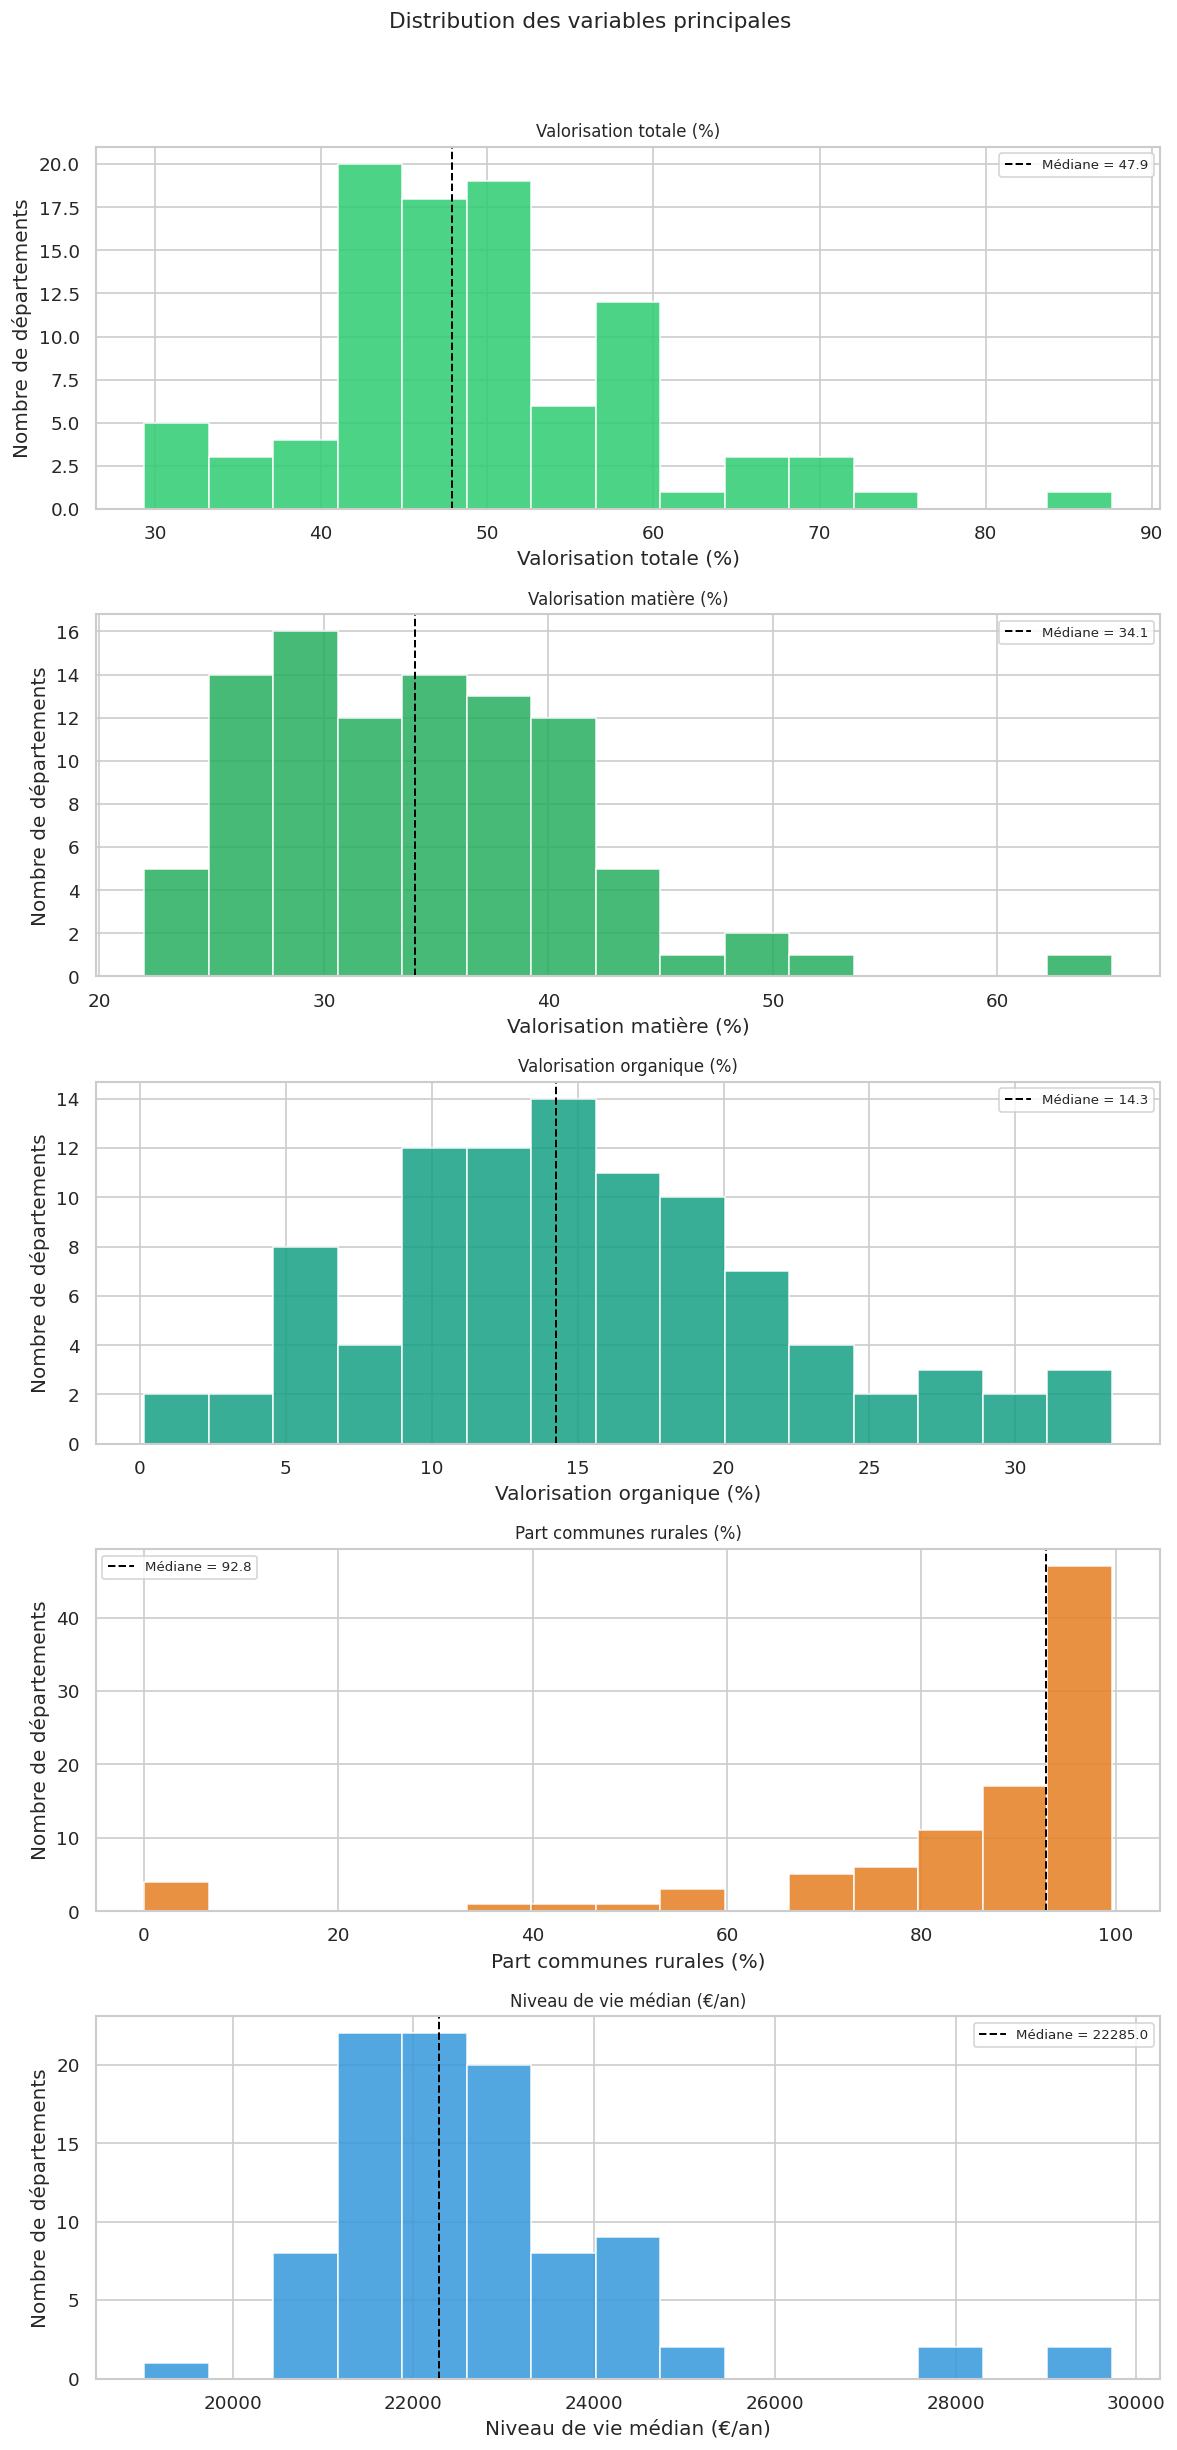

In [ ]:
# On fait des histogrammes  (5)
fig, axes = plt.subplots(5, 1, figsize=(10, 20))

for ax, (col, color, label) in zip(axes, configs_distrib):
    # Histogramme de la distribution
    ax.hist(df[col].dropna(), bins=15, color=color, edgecolor="white", alpha=0.85)

    # Ligne verticale de la médiane
    mediane = df[col].median()
    ax.axvline(mediane, color="black", linestyle="--", linewidth=1.2,
               label=f"Médiane = {mediane:.1f}")

    ax.set_title(label, fontsize=10)
    ax.set_xlabel(label)
    ax.set_ylabel("Nombre de départements")
    ax.legend(fontsize=8)

plt.suptitle("Distribution des variables principales", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Analyse :** La distribution du taux de valorisation est relativement symétrique autour de la médiane. La ruralité présente une distribution bimodale (départements très ruraux vs. très urbains), ce qui pourra générer une relation non-linéaire avec la valorisation. Le niveau de vie médian est quant à lui concentré autour d'une plage relativement étroite, avec quelques départements à fort revenu.

### 3.2 Nuages de points : ruralité, niveau de vie et valorisation

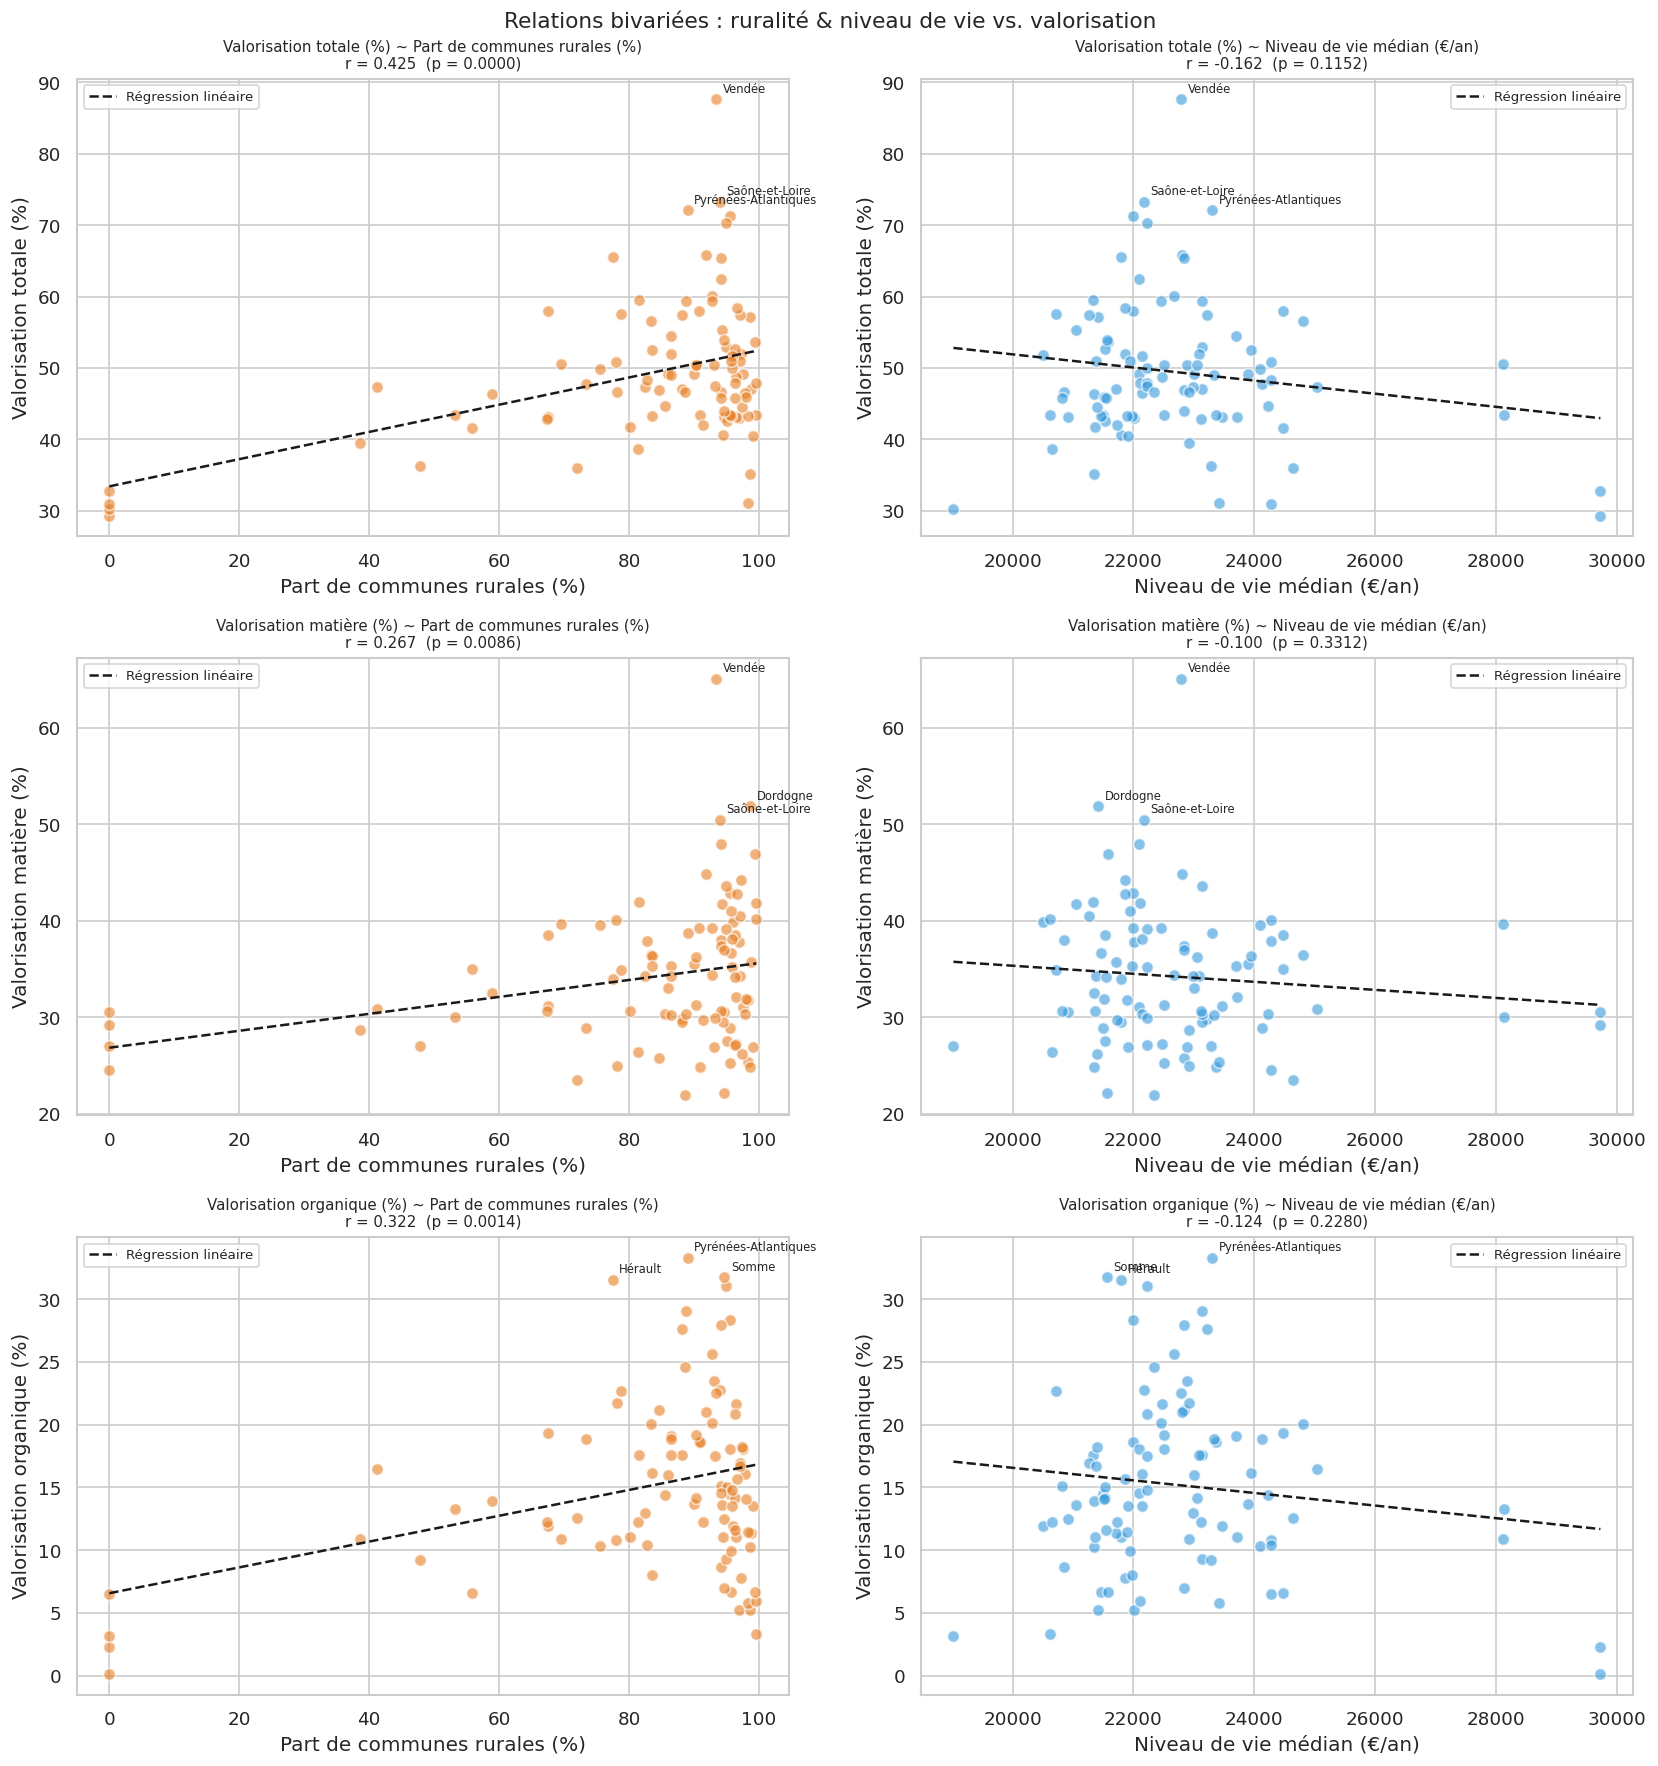

In [39]:
# Grille 3×2 : 3 indicateurs × 2 variables explicatives 
# Lignes : valorisation totale / matière / organique
# Colonnes : ruralité / niveau de vie

fig, axes = plt.subplots(3, 2, figsize=(14, 15))

lignes = [
    ("taux_valo_total_pct",     "Valorisation totale (%)"),
    ("taux_valo_matiere_pct",   "Valorisation matière (%)"),
    ("taux_valo_organique_pct", "Valorisation organique (%)"),
]
colonnes = [
    ("part_communes_rurales_pct", "Part de communes rurales (%)", "#e67e22"),
    ("niveau_vie_median",          "Niveau de vie médian (€/an)", "#3498db"),
]

for i, (y_col, y_label) in enumerate(lignes):
    for j, (x_col, x_label, color) in enumerate(colonnes):
        scatter_regression(axes[i][j],df, x_col, y_col, x_label, y_label, color) 
        axes[i][j].set_xlabel(x_label)
        axes[i][j].set_ylabel(y_label)

plt.suptitle("Relations bivariées : ruralité & niveau de vie vs. valorisation",
             fontsize=13)
plt.tight_layout()
plt.show()

**Analyse :**
Dans l'ensemble, les régressions ne semblent pas très représentatives des données qui sont très dispersées.

- **Ruralité (gauche)** : la droite de régression est ascendante, confirmant une relation positive entre part de communes rurales et taux de valorisation. Le coefficient de corrélation de Pearson est modéré mais significatif. Cela se retrouve aussi bien pour le total que por les deux types de valorisation.
- **Niveau de vie (droite)** : la pente est quasi-nulle et la p-value dépasse le seuil de 5 %. Il n'y a pas de relation linéaire claire entre le revenu médian et la valorisation des déchets à l'échelle départementale.
- Les départements annotés (outliers) sont ceux dont les résidus sont les plus importants, c'est-à-dire ceux dont le comportement s'écarte le plus de la tendance générale — ils méritent une attention particulière.

### 3.3 Heatmap de corrélation
Petit rappel :
La corrélation de Pearson mesure la "justesse" d'une relation **linéaire** :
 - +1 : relation positive parfaite
 -  0 : aucune relation linéaire
 - −1 : relation négative parfaite



In [40]:
# Calcul de la matrice de corrélation 
vars_corr  = ["taux_valo_total_pct", "taux_valo_matiere_pct", "taux_valo_organique_pct",
              "part_communes_rurales_pct", "niveau_vie_median"]
labels_corr = ["Valo. totale", "Valo. matière", "Valo. organique",
               "Ruralité", "Niveau de vie"]


# dropna() : on retire les départements avec des valeurs manquantes
# pour que toutes les corrélations soient calculées sur le même ensemble, sinon cela ne fonctionne pas et garde des cases blanches
mat_corr = df[vars_corr].dropna().corr().round(3)

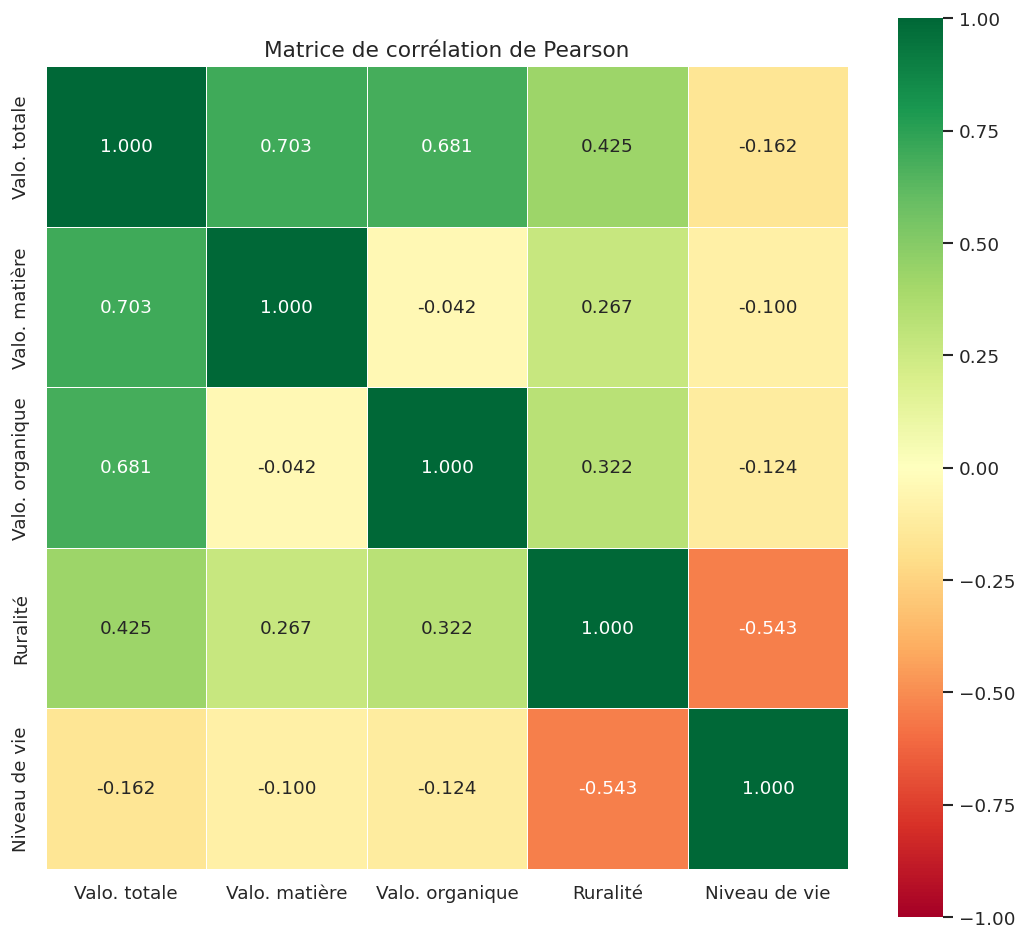

In [41]:
# Affichage de la heatmap 
fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(
    mat_corr,
    annot=True,         
    fmt=".3f",
    cmap="RdYlGn",     
    vmin=-1, vmax=1,
    xticklabels=labels_corr,
    yticklabels=labels_corr,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 11},  # taille des valeurs dans les cellules
    ax=ax,
)
#  annot permet de mettre les valeurs dans les cases et cmap est définit pour que le rouge soit pour le négatif et le vert pour le positif
ax.set_title("Matrice de corrélation de Pearson", fontsize=13)
ax.tick_params(axis="x", labelsize=11)  
ax.tick_params(axis="y", labelsize=11) 
plt.tight_layout()
plt.show()

**Lecture :** La heatmap confirme que la corrélation la plus forte avec le taux de valorisation est celle de la ruralité (valeur positive modérée). On note également une corrélation négative entre ruralité et niveau de vie — les départements ruraux sont en moyenne moins riches — ce qui soulève un risque de colinéarité partielle entre les deux variables explicatives. Malgré tout, les coefficients demeurent assez éloignés du 1 ou du -1 ce qui correspond à ce que l'on pouvait penser de la visualisation des droites de régression et sur les données. 

### Distributions des modes de transport

Un **boxplot** (boîte à moustaches) permet de visualiser la distribution d'une variable numérique

In [ ]:
from fonctions import afficher_gt_part_modale
# AFFICHAGE

# Affichage pour 2016 (on filtre les 10 premières lignes du DataFrame)
gt_2016 = afficher_gt_part_modale(tables_par_annee[2016].head(10), 2016)
display(gt_2016)

# Affichage pour 2022 (on filtre les 10 premières lignes du DataFrame)
gt_2022 = afficher_gt_part_modale(tables_par_annee[2022].head(10), 2022)
display(gt_2022)

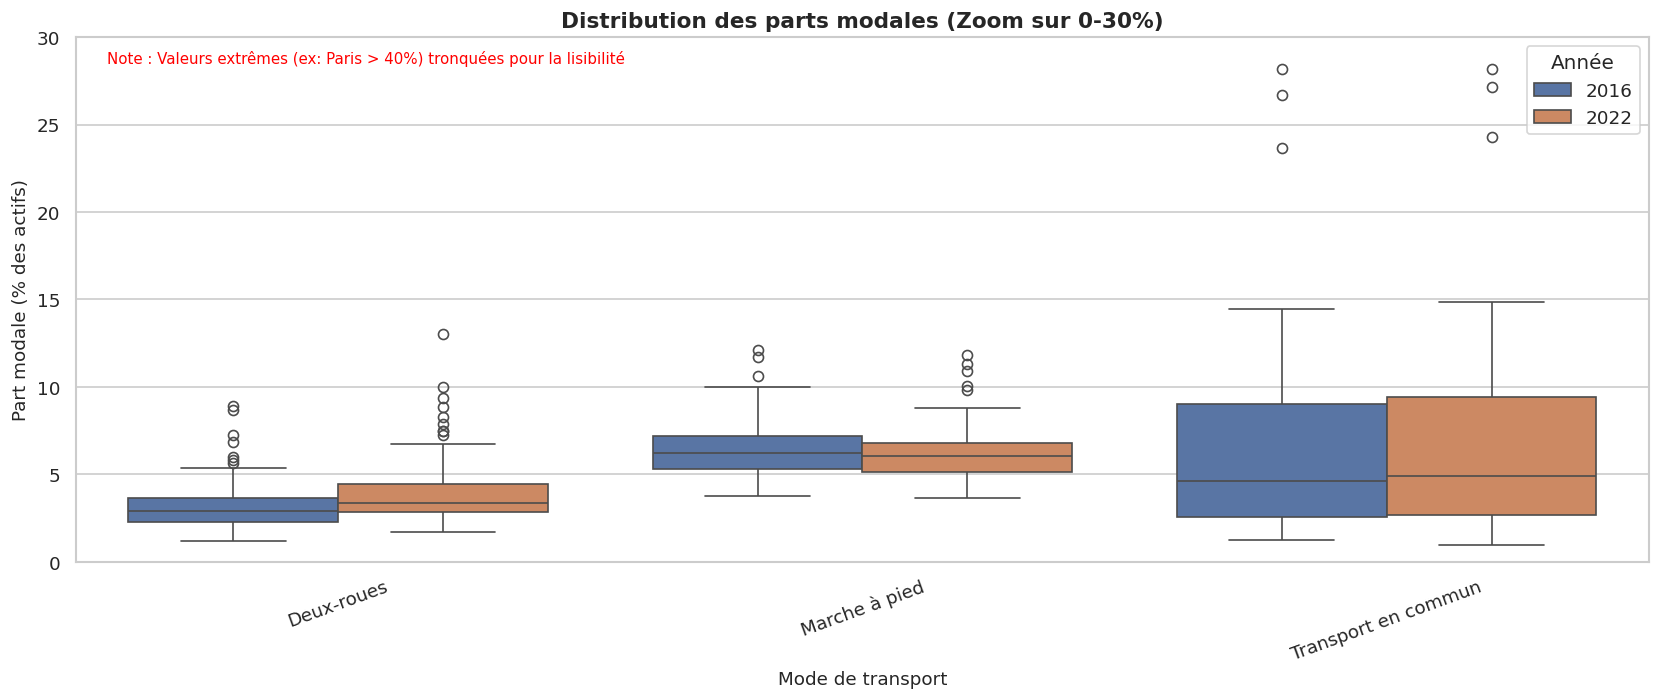

In [21]:
# Comparaison des distributions de parts modales entre 2016 et 2022
# On prépare les données en format "long" pour seaborn

# Modes de transport douces
modes = ['Deux-roues', 'Marche à pied', 'Transport en commun']

frames = []
for annee in [2016, 2022]:
    for mode in modes:
        try:
            serie = tables_par_annee[annee].xs(mode, axis=1, level=1).squeeze()
            tmp = pd.DataFrame({'Part_modale': serie.values, 'Mode': mode, 'Annee': str(annee)})
            frames.append(tmp)
        except KeyError:
            pass

df_long = pd.concat(frames, ignore_index=True)

# Boxplot comparatif
fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=df_long,
    x='Mode', y='Part_modale', hue='Annee',
    palette={'2016': '#4C72B0', '2022': '#DD8452'},
    ax=ax,
    # Optionnel : masquer les points aberrants s'ils polluent trop
    showfliers=True 
)

# --- SOLUTION POUR "LIMER" L'AFFICHAGE ---
# On limite l'axe Y à 30% pour mieux voir les boîtes
ax.set_ylim(0, 30) 

ax.set_title("Distribution des parts modales (Zoom sur 0-30%)", fontsize=13, fontweight='bold')
ax.set_xlabel("Mode de transport", fontsize=11)
ax.set_ylabel("Part modale (% des actifs)", fontsize=11)
ax.tick_params(axis='x', rotation=20)
ax.legend(title='Année')

# Petit ajout : une note pour prévenir que les extrêmes sont hors champ
ax.annotate('Note : Valeurs extrêmes (ex: Paris > 40%) tronquées pour la lisibilité', 
            xy=(0.02, 0.95), xycoords='axes fraction', fontsize=9, color='red')

plt.tight_layout()
plt.show()

### Top 10 des départements par mode de transport (2022)

On identifie les **10 départements** où chaque mode est le plus utilisé en 2022. Cela permet de repérer les **territoires moteurs** ou au contraire les plus dépendants d'un seul mode.

In [22]:
# Top 10 départements par mode en 2022
print("=" * 55)
print(" TOP 5 DÉPARTEMENTS PAR MODE DE TRANSPORT EN 2022")
print("=" * 55)

for mode in modes:
    try:
        serie = tables_par_annee[2022].xs(mode, axis=1, level=1).squeeze()
        top5 = serie.nlargest(5)
        print(f"\n🔹 {mode}")
        for dep, val in top5.items():
            print(f"   Département {dep} : {val:.1f} %")
    except KeyError:
        pass

 TOP 5 DÉPARTEMENTS PAR MODE DE TRANSPORT EN 2022

🔹 Deux-roues
   Département 75 : 13.0 %
   Département 92 : 10.0 %
   Département 06 : 9.4 %
   Département 67 : 8.8 %
   Département 33 : 8.3 %

🔹 Marche à pied
   Département 05 : 11.8 %
   Département 75 : 11.3 %
   Département 48 : 10.9 %
   Département 92 : 10.1 %
   Département 15 : 9.8 %

🔹 Transport en commun
   Département 75 : 61.2 %
   Département 93 : 50.9 %
   Département 94 : 48.2 %
   Département 92 : 47.8 %
   Département 95 : 36.4 %


## Analyse des évolutions 2016-2022

On calcule maintenant la **variation** de la part modale de chaque mode entre 2016 et 2022, pour chaque département.

$$\text{Évolution} = \text{Part}_{2022} - \text{Part}_{2016} \quad (\text{en points de pourcentage})$$

Une valeur **positive** signifie que le mode a **gagné du terrain** dans ce département ; une valeur **négative** qu'il en a **perdu**.

In [ ]:
# Calcul de la différence (2022 - 2016)
df_evol = tables_par_annee[2022] - tables_par_annee[2016]

print("--- ÉVOLUTION 2016-2022 (en points) ---")
print(df_evol.head())

--- ÉVOLUTION 2016-2022 (en points) ---
TRANS                    1             2        3T4  \
LIB_TRANS Pas de transport Marche à pied Deux-roues   
GEO                                                   
01                   -0.40         -0.28       0.84   
02                   -0.66         -0.77      -0.03   
03                   -0.87         -0.31       0.38   
04                   -0.41         -0.83       0.75   
05                   -0.15         -0.28       0.86   

TRANS                                   5                   6  
LIB_TRANS Voiture, camion ou fourgonnette Transport en commun  
GEO                                                            
01                                  -0.49                0.34  
02                                   1.58               -0.12  
03                                   0.84               -0.04  
04                                   0.31                0.19  
05                                  -0.29               -0.14  


### Statistiques descriptives des évolutions

Examinons les distributions des évolutions pour comprendre les tendances nationales.

In [ ]:
# Statistiques descriptives des évolutions par mode
print("=" * 55)
print(" ÉVOLUTION DES MODES DE TRANSPORT 2016→2022 (en points)")
print("=" * 55)

df_evol_stats = pd.DataFrame()
for mode in modes:
    try:
        serie = df_evol.xs(mode, axis=1, level=1).squeeze()
        df_evol_stats[mode] = serie.values
    except KeyError:
        pass

stats_evol = df_evol_stats.describe().round(3)
print(stats_evol)

print("\n── Interprétation ──")
for col in df_evol_stats.columns:
    moy = df_evol_stats[col].mean()
    direction = "↗ en hausse" if moy > 0 else "↘ en baisse"
    print(f"  {col} : {direction} en moyenne ({moy:+.2f} pts)")

 ÉVOLUTION DES PARTS MODALES 2016→2022 (en points)
       Deux-roues  Marche à pied  Transport en commun
count       96.00          96.00                96.00
mean         0.78          -0.29                 0.21
std          0.71           0.33                 0.57
min         -0.06          -1.09                -3.27
25%          0.38          -0.46                -0.02
50%          0.55          -0.29                 0.20
75%          0.89          -0.10                 0.37
max          4.13           1.33                 1.86

── Interprétation ──
  Deux-roues : ↗ en hausse en moyenne (+0.78 pts)
  Marche à pied : ↘ en baisse en moyenne (-0.29 pts)
  Transport en commun : ↗ en hausse en moyenne (+0.21 pts)


### Visualisation des évolutions

Un **histogramme** montre la répartition des évolutions départementales. Si la distribution est centrée à droite de zéro, le mode a progressé dans la majorité des départements.

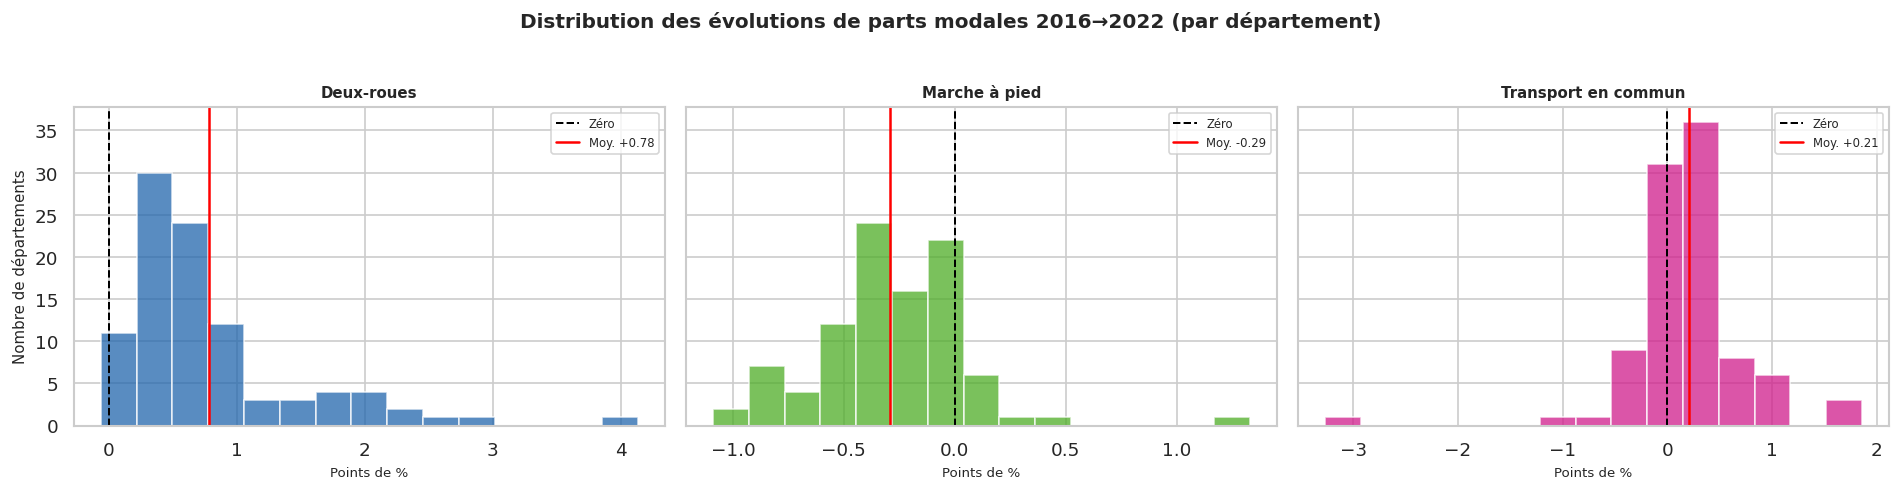


→ La ligne pointillée noire marque le zéro (pas d'évolution).
  La ligne rouge indique la moyenne nationale de l'évolution.
  Un histogramme décalé à droite signifie une progression généralisée du mode.


In [27]:
# Histogrammes des évolutions par mode de transport
fig, axes = plt.subplots(1, len(df_evol_stats.columns), figsize=(16, 4), sharey=True)

colors = ['#2166ac', '#4dac26', '#d01c8b', '#f1a340', '#998ec3']

for ax, (col, color) in zip(axes, zip(df_evol_stats.columns, colors)):
    data = df_evol_stats[col].dropna()
    ax.hist(data, bins=15, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(0, color='black', linestyle='--', linewidth=1.2, label='Zéro')
    ax.axvline(data.mean(), color='red', linestyle='-', linewidth=1.5, label=f'Moy. {data.mean():+.2f}')
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_xlabel("Points de %", fontsize=8)
    ax.legend(fontsize=7)

axes[0].set_ylabel("Nombre de départements", fontsize=9)
fig.suptitle("Distribution des évolutions de parts modales 2016→2022 (par département)",
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n→ La ligne pointillée noire marque le zéro (pas d'évolution).")
print("  La ligne rouge indique la moyenne nationale de l'évolution.")
print("  Un histogramme décalé à droite signifie une progression généralisée du mode.")

### Départements avec les évolutions les plus marquées

On identifie les **10 départements** qui ont le plus progressé et les **10 qui ont le plus reculé** pour les deux-roues et les transports en commun — les deux modes dont l'évolution est au cœur des politiques de mobilité durable.

In [28]:
from fonctions import extraire_extremes

# 1. Extraction et nettoyage
# On récupère les colonnes d'évolution (en points de %)
evol_2roues = df_evol.xs('Deux-roues', axis=1, level=1)
evol_tc = df_evol.xs('Transport en commun', axis=1, level=1)

# --- AFFICHAGE ---
extraire_extremes(evol_2roues, "Deux-roues")
extraire_extremes(evol_tc, "Transports en commun")


--- DEUX-ROUES : Les plus fortes PROGRESSIONS ---
GEO
75   4.13
69   2.77
92   2.73
44   2.35
33   2.33

--- DEUX-ROUES : Les plus forts RECULS ---
GEO
2A   -0.06
02   -0.03
89    0.03
60    0.05
2B    0.06

--- TRANSPORTS EN COMMUN : Les plus fortes PROGRESSIONS ---
GEO
78   1.86
06   1.56
74   1.53
33   1.08
94   1.06

--- TRANSPORTS EN COMMUN : Les plus forts RECULS ---
GEO
75   -3.27
90   -0.99
70   -0.56
28   -0.51
2A   -0.30



**Deux-roues :** La progression est souvent plus forte dans les grandes villes et agglomérations universitaires, où les politiques cyclables (pistes, vélos en libre-service) ont été actives entre 2016 et 2022. La période Covid (2020-2021) a également boosté la pratique du vélo.

**Transports en commun :** Les évolutions sont contrastées. Certains territoires ayant développé leur réseau (tramway, RER, etc.) ont vu leur part progresser.


### 3.4 Analyse cartographique : les cartes choroplèthes

Rappel : Une carte choroplèthe colorie chaque département selon l'intensité d'une variable : plus la couleur est foncée, plus la valeur est élevée.

In [42]:
# Chargement du fond de carte 
# Le GeoJSON contient les contours géographiques des 96 départements métropolitains.
carte_base = gpd.read_file(GEOJSON_URL)

# Harmonisation du code pour la jointure
carte_base["code"] = carte_base["code"].astype(str).str.zfill(2)
df["code_dept"]    = df["code_dept"].astype(str).str.zfill(2)

# Jointure : on enrichit chaque polygone géographique avec nos données
carte = carte_base.merge(df, left_on="code", right_on="code_dept", how="left")
print(f"Carte chargée : {len(carte)} départements")

Carte chargée : 96 départements


NameError: name 'configs_cartes' is not defined

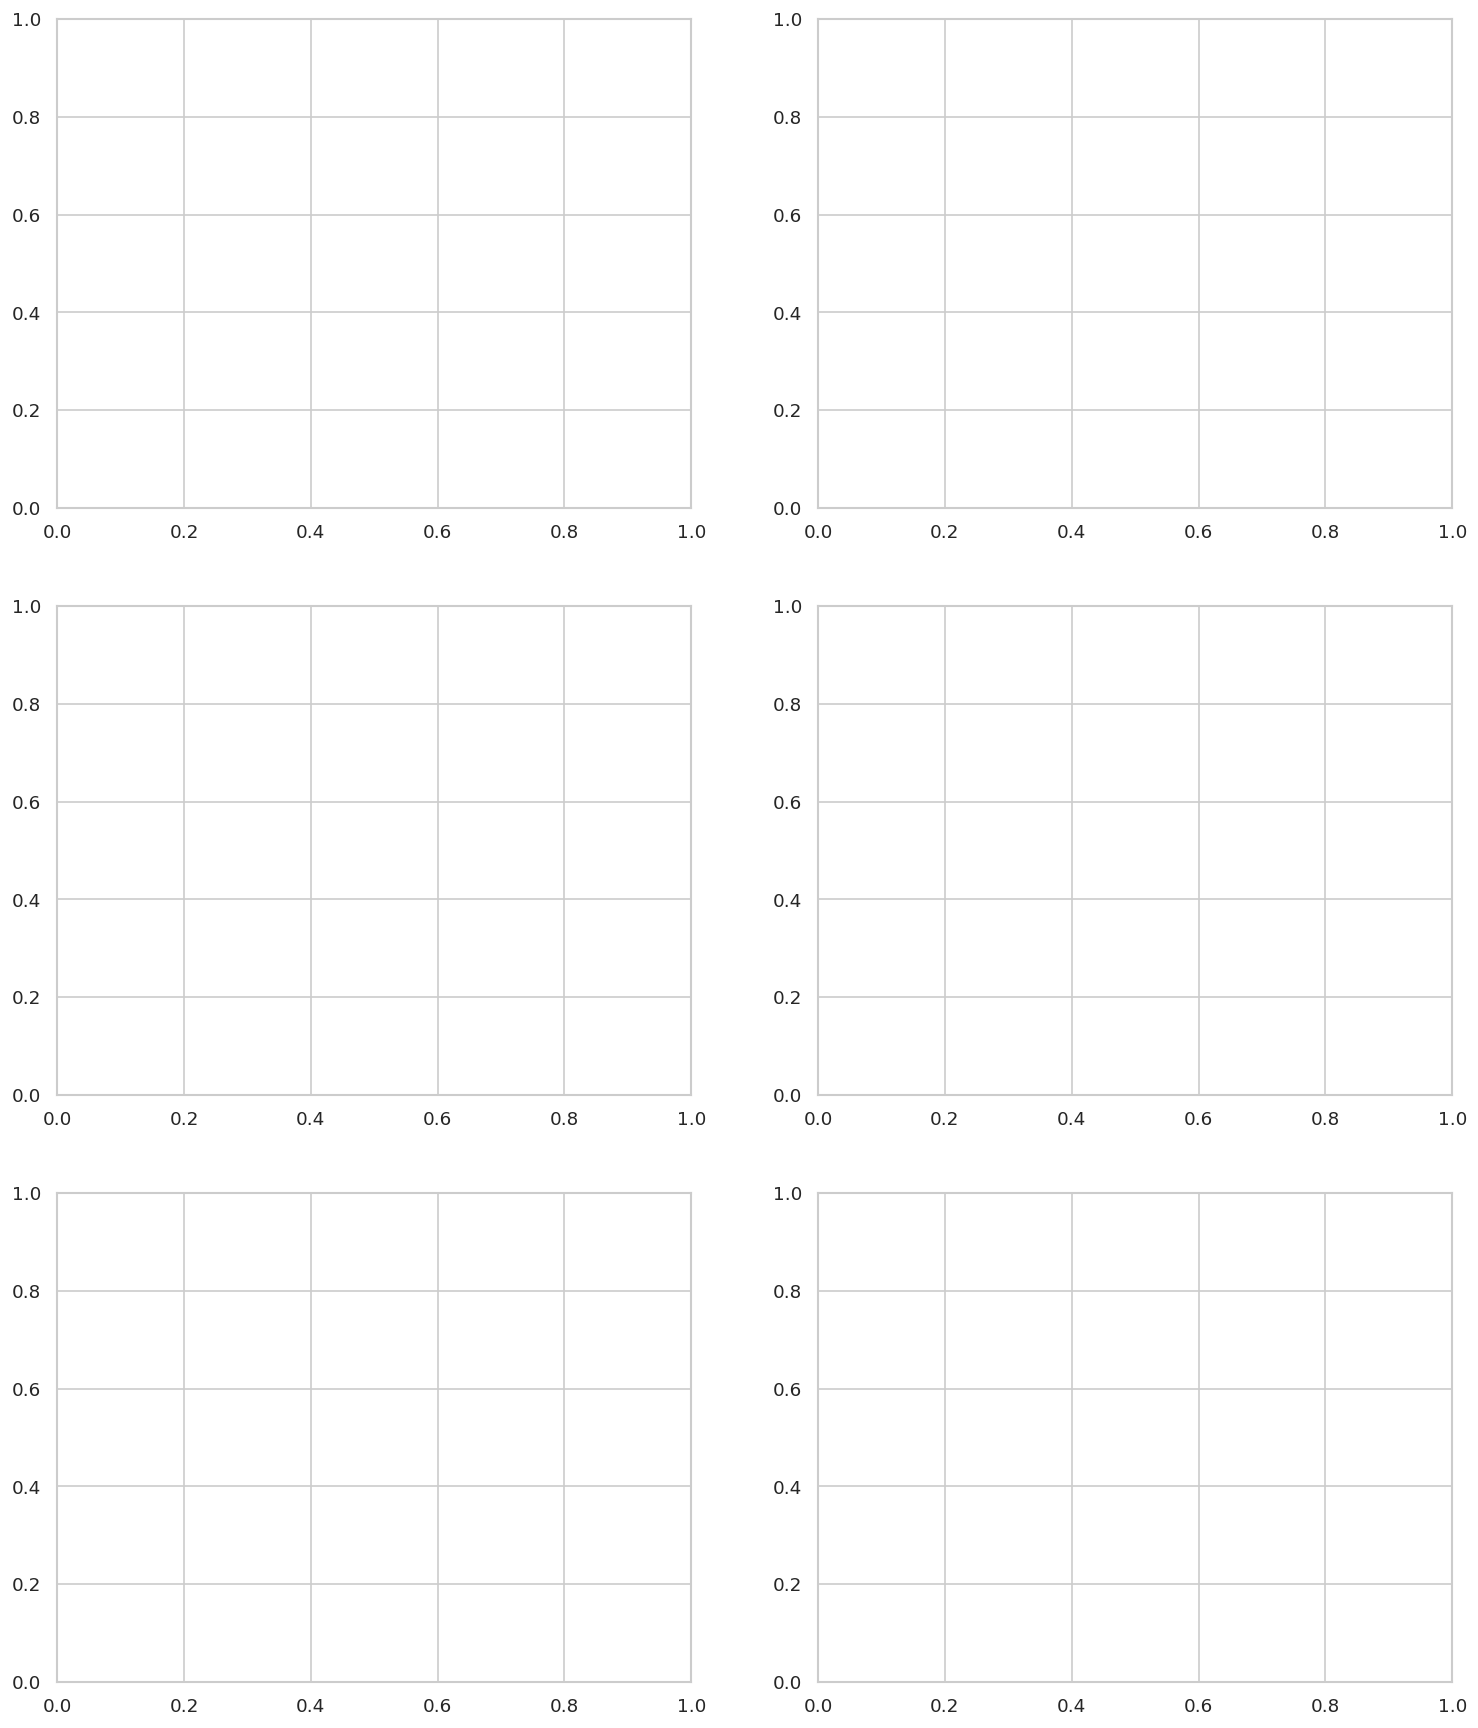

In [29]:
# Cartes choroplèthes : 5 variables l'une après l'autre

# 1. Configuration de la grille : 3 lignes et 2 colonnes (6 emplacements pour 5 cartes)
# figsize : on réduit la hauteur et on augmente la largeur
fig, axes = plt.subplots(3, 2, figsize=(15, 18))

# 2. On "aplatit" le tableau d'axes (qui est en 2D) pour pouvoir boucler facilement
axes_flat = axes.flatten()

# 3. Boucle sur vos configurations
for i, (col, cmap, title) in enumerate(configs_cartes):
    ax = axes_flat[i]  # On récupère l'emplacement actuel
    
    carte.plot(
        column=col,
        cmap=cmap,
        linewidth=0.4,
        edgecolor="white",
        legend=True,
        legend_kwds={"shrink": 0.6, "label": title},
        ax=ax,
        missing_kwds={"color": "lightgrey", "label": "Donnée manquante"},
    )
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.axis("off")

# 4. On cache le 6ème emplacement (le dernier) car on n'a que 5 cartes
axes_flat[-1].axis("off")

plt.suptitle("Répartition spatiale des variables à l'échelle départementale", 
             fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

**Lecture des cartes :**
- La carte de valorisation (verte) révèle une **concentration des bons performeurs dans les zones rurales** (diagonale nord-est / sud-ouest et Massif Central), alors que les grandes métropoles et leurs couronnes affichent des taux plus faibles. On repère notamment quelques "bons élèves" notamment sur la cote atlantlique.
- La carte de ruralité (orange) montre une structure spatiale similaire, ce qui renforce visuellement la corrélation positive entre les deux variables.
- La carte de niveau de vie (bleue) présente un gradient différent, plus concentré autour de l'Île-de-France et de quelques métropoles. Sa géographie est donc distincte de celle de la valorisation, cohérent avec l'absence de corrélation significative observée statistiquement.

### 3.5 Carte typologique : 4 profils territoriaux

 On croise deux dimensions binaires :
 - Rural / Urbain (au-dessus / en-dessous de la médiane nationale de ruralité)
 - Valorisation forte / faible (au-dessus / en-dessous de la médiane nationale)

 On identifie 4 profils : les cas "rural / valorisation faible" sont particulièrement intéressants car ils montrent que la ruralité seule ne suffit pas.


In [44]:
#  Calcul des seuils (médianes nationales) 
med_valo  = df["taux_valo_total_pct"].median()
med_rural = df["part_communes_rurales_pct"].median()

ordre_profils = [
    "Urbain / valorisation faible",
    "Urbain / valorisation forte",
    "Rural  / valorisation faible",
    "Rural  / valorisation forte",
]
df["profil"] = pd.Categorical(
    df.apply(lambda row: attribuer_profil(row, med_valo, med_rural), axis=1),
    categories=ordre_profils,
    ordered=True,
)

print(f"Seuil valorisation : {med_valo:.1f}%")
print(f"Seuil ruralité     : {med_rural:.1f}%")

Seuil valorisation : 47.9%
Seuil ruralité     : 92.8%


In [45]:
#On complete les profils 
print("Répartition des profils :")
display(df["profil"].value_counts().rename("Nombre de départements").to_frame())


Répartition des profils :


,Nombre de départements
profil,
Urbain / valorisation faible,25
Rural / valorisation forte,25
Urbain / valorisation forte,23
Rural / valorisation faible,23


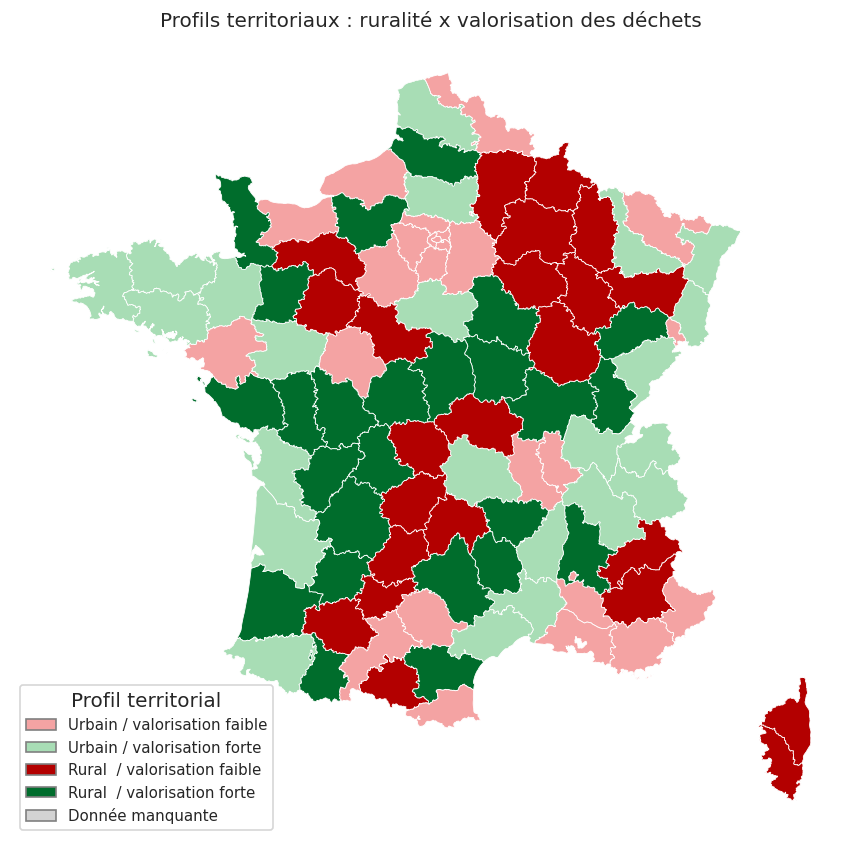

In [46]:
#  On trace la carte typologique
# Palette : rouge/vert selon la valorisation, clair/foncé selon la ruralité
couleurs_profil = {
    "Urbain / valorisation faible": "#f4a3a3",  # rose clair
    "Urbain / valorisation forte":  "#a8ddb5",  # vert clair
    "Rural  / valorisation faible": "#b30000",  # rouge foncé
    "Rural  / valorisation forte":  "#006d2c",  # vert foncé
}

# Rechargement de la carte avec la colonne profil
carte2 = carte_base.merge(df, left_on="code", right_on="code_dept", how="left")
carte2["couleur"] = carte2["profil"].map(couleurs_profil)

fig, ax = plt.subplots(figsize=(9, 10))

# On passe color= (discret) et non column= (gradient continu)
carte2.plot(
    color=carte2["couleur"].astype(object).fillna("lightgrey"),
    linewidth=0.5,
    edgecolor="white",
    ax=ax,
)

# Légende manuelle avec des patches colorés
patches = [
    mpatches.Patch(facecolor=v, edgecolor="grey", label=k)
    for k, v in couleurs_profil.items()
]
patches.append(mpatches.Patch(facecolor="lightgrey", edgecolor="grey",
                               label="Donnée manquante"))
ax.legend(handles=patches, title="Profil territorial",
          loc="lower left", frameon=True, fontsize=9)
ax.set_title("Profils territoriaux : ruralité x valorisation des déchets",
             fontsize=12)
ax.axis("off")
plt.show()

**Analyse :**
La carte fait ressortir une concentration des profils "rural / valorisation forte" (vert foncé) dans les zones à forte tradition agricole (Massif Central, Bretagne intérieure, Grand Est rural). Les profils "rural / valorisation faible" (rouge foncé) sont des cas qui montrent que la ruralité seule ne garantit pas de bonnes performances, d'autres facteurs comme l'organisation des filières ou la densité d'équipements jouent un rôle. Les profils urbains sont plus dispersés géographiquement. 

### 3.6 Clustering K-Means

Dans la section précédente, on a construit les profils "à la main" en coupant au niveau des médianes. C'est simple, mais ça impose des seuils arbitraires.

Le K-Means fonctionne différemment : on lui donne les données brutes et il cherche lui-même des groupes de départements qui se ressemblent, en minimisant la distance entre les points d'un même groupe.

On l'applique sur 3 variables : valorisation totale, ruralité et niveau de vie.
L'idée est de voir si des profils cohérents émergent naturellement — et si ces profils recoupent ceux qu'on a définis manuellement.


In [47]:

# Sélection des variables et suppression des valeurs manquantes
X = df[["taux_valo_total_pct", "part_communes_rurales_pct", "niveau_vie_median"]].dropna()

In [48]:
# Normalisation obligatoire pour K-Means
#car sinon niveau_vie_median (20 000-30 000 €) écraserait les autres variables (0-100 %)
# StandardScaler : transforme chaque variable pour avoir moyenne=0 et écart-type=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

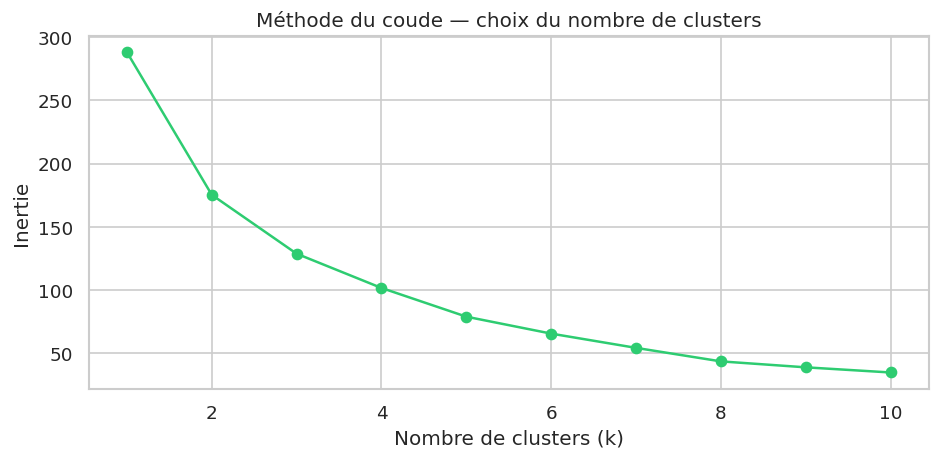

In [49]:
# Méthode du coude : on teste k=1 à 10 et on trace l'inertie
# L'inertie mesure la dispersion interne des clusters — plus elle est basse, mieux c'est
# On cherche le "coude" : le point où l'inertie cesse de baisser fortement
inerties = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inerties.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inerties, marker="o", color="#2ecc71")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie")
plt.title("Méthode du coude — choix du nombre de clusters")
plt.tight_layout()
plt.show()

Le coude n'est pas très marqué — on hésite entre k=3 et k=4. On retient k=4
pour pouvoir comparer avec les 4 profils de la section précédente, mais k=3
aurait aussi été défendable.

In [50]:
# On choisit k=4 pour comparer avec nos 4 profils manuels de la carte typologique
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df.loc[X.index, "cluster"] = kmeans.fit_predict(X_scaled)
df["cluster"] = df["cluster"].astype("Int64")  
# Int64 gère les NaN

In [51]:
# Profil moyen de chaque cluster
# Permet de comprendre ce qui caractérise chaque groupe
display(
    df.groupby("cluster")[["taux_valo_total_pct", "part_communes_rurales_pct",
                            "niveau_vie_median"]]
    .mean().round(2)
)

,taux_valo_total_pct,part_communes_rurales_pct,niveau_vie_median
cluster,,,
0,46.48,90.30,22385.94
1,39.03,30.70,28925.00
2,63.07,89.81,22382.73
3,37.66,30.59,23170.00


**Lecture des clusters :**
- **Cluster 0** : départements ruraux à forte valorisation organique — correspondent aux profils "rural / valorisation forte"
- **Cluster 1** : départements urbains à faible valorisation — grandes métropoles
- **Cluster 2** : départements intermédiaires — ni très ruraux ni très urbains
- **Cluster 3** : départements ruraux à faible valorisation organique malgré la ruralité


Les clusters 0 et 2 sont tous les deux très ruraux avec des revenus quasi
identiques (~22 400€) — pourtant leur taux de valorisation diffère de 17 points
(46% vs 63%). C'est le résultat le plus intéressant : la ruralité seule
n'explique pas tout, l'organisation locale des filières de tri semble jouer
un rôle important.

Du côté urbain, les clusters 1 et 3 ont des niveaux de vie différents mais
des taux de valorisation similaires (~38-39%). Ça confirme ce qu'on voyait
dans la régression : le revenu ne joue pas vraiment..



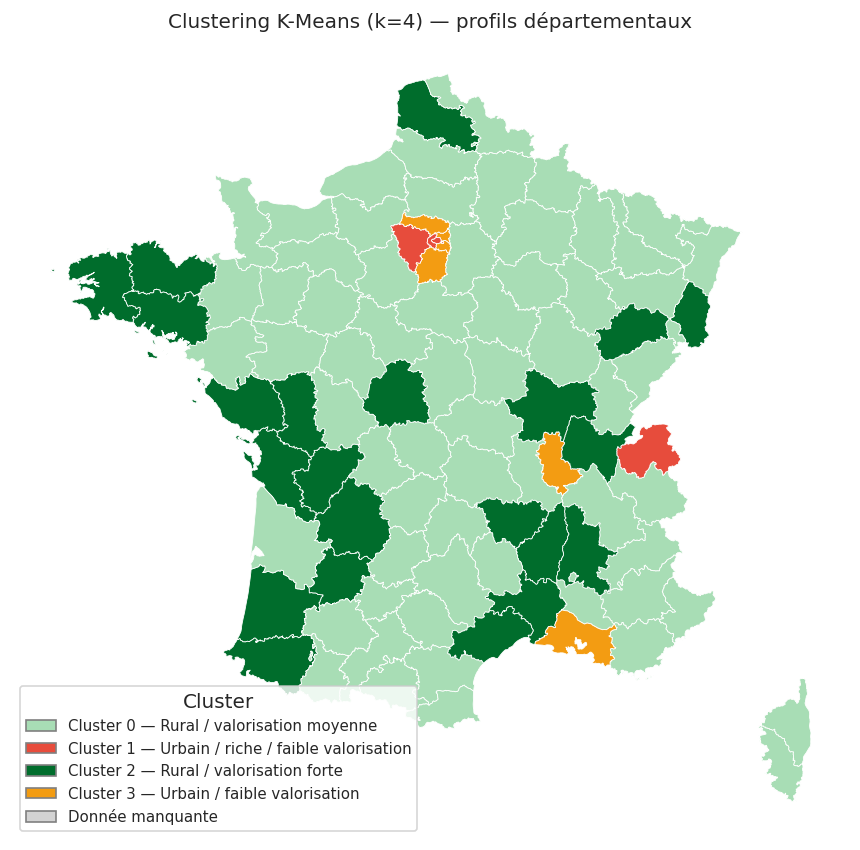

In [ ]:
# Carte choroplèthe des clusters avec couleurs personnalisées
carte3 = carte_base.merge(df[["code_dept", "cluster"]], 
                           left_on="code", right_on="code_dept", how="left")

# Palette manuelle : une couleur par cluster selon le profil
# vert foncé = rural fort, vert clair = rural moyen, jaune = rural faible, rouge = urbain faible


palette_clusters = {
    "0": "#a8ddb5",   # vert clair  — rural / valorisation moyenne
    "1": "#e74c3c",   # rouge       — urbain / riche / faible valorisation
    "2": "#006d2c",   # vert foncé  — rural / valorisation forte
    "3": "#f39c12",   # jaune/orange — urbain / faible valorisation
}

carte3["cluster"] = carte3["cluster"].astype(str)
carte3["couleur"] = carte3["cluster"].map(palette_clusters)

fig, ax = plt.subplots(figsize=(9, 10))
carte3.plot(
    color=carte3["couleur"].astype(object).fillna("lightgrey"),
    linewidth=0.5,
    edgecolor="white",
    ax=ax,
)

# Légende manuelle
labels = {
    "0": "Cluster 0 — Rural / valorisation moyenne",
    "1": "Cluster 1 — Urbain / riche / faible valorisation",
    "2": "Cluster 2 — Rural / valorisation forte",
    "3": "Cluster 3 — Urbain / faible valorisation",
}
patches = [
    mpatches.Patch(facecolor=palette_clusters[k], edgecolor="grey", label=v)
    for k, v in labels.items()
]
patches.append(mpatches.Patch(facecolor="lightgrey", edgecolor="grey", label="Donnée manquante"))
ax.legend(handles=patches, title="Cluster", loc="lower left", frameon=True, fontsize=9)

ax.set_title("Clustering K-Means (k=4) — profils départementaux", fontsize=12)
ax.axis("off")
plt.show()



**Analyse de la carte des clusters :**
La carte confirme visuellement ce qu'on voyait dans les chiffres. Le vert
clair (cluster 0) domine largement — c'est la France rurale "ordinaire".

Ce qui saute aux yeux, c'est la Bretagne et les Pays de la Loire en vert
foncé (cluster 2) : des départements ruraux comme les autres sur le papier,
mais avec une valorisation nettement meilleure. On peut supposer que ces
régions ont développé des filières de compostage et de collecte sélective
plus efficaces, mais ça mériterait d'être creusé.

Paris et sa couronne forment une tache rouge isolée — urbanisation dense,
peu de place pour le compostage individuel, logistique de collecte plus
complexe. 


## 4. Modélisation

### 4.1 Corrélations bivariées

In [53]:
# Corrélations : ruralité vs les 3 indicateurs 
print("=" * 60)
print("RURALITÉ X VALORISATION")
print("=" * 60)
afficher_correlations(df,"part_communes_rurales_pct", "taux_valo_total_pct",
                      "Ruralité", "Valorisation totale")
afficher_correlations(df,"part_communes_rurales_pct", "taux_valo_matiere_pct",
                      "Ruralité", "Valorisation matière")
afficher_correlations(df,"part_communes_rurales_pct", "taux_valo_organique_pct",
                      "Ruralité", "Valorisation organique")


RURALITÉ X VALORISATION
  Ruralité × Valorisation totale
  Pearson  r = 0.425  (p = 0.000016)
  Spearman ρ = 0.139  (p = 0.177203)
  → significatif au seuil 5 %

  Ruralité × Valorisation matière
  Pearson  r = 0.267  (p = 0.008607)
  Spearman ρ = 0.227  (p = 0.026364)
  → significatif au seuil 5 %

  Ruralité × Valorisation organique
  Pearson  r = 0.322  (p = 0.001376)
  Spearman ρ = -0.046  (p = 0.654252)
  → significatif au seuil 5 %



In [54]:
# Corrélations : niveau de vie vs les 3 indicateurs 
print("=" * 60)
print("NIVEAU DE VIE X VALORISATION")
print("=" * 60)
afficher_correlations(df,"niveau_vie_median", "taux_valo_total_pct",
                      "Niveau de vie", "Valorisation totale")
afficher_correlations(df,"niveau_vie_median", "taux_valo_matiere_pct",
                      "Niveau de vie", "Valorisation matière")
afficher_correlations(df,"niveau_vie_median", "taux_valo_organique_pct",
                      "Niveau de vie", "Valorisation organique")

NIVEAU DE VIE X VALORISATION
  Niveau de vie × Valorisation totale
  Pearson  r = -0.162  (p = 0.115179)
  Spearman ρ = -0.028  (p = 0.784731)
  → non significatif au seuil 5 %

  Niveau de vie × Valorisation matière
  Pearson  r = -0.100  (p = 0.331167)
  Spearman ρ = -0.134  (p = 0.191642)
  → non significatif au seuil 5 %

  Niveau de vie × Valorisation organique
  Pearson  r = -0.124  (p = 0.228036)
  Spearman ρ = 0.062  (p = 0.547383)
  → non significatif au seuil 5 %



**Analyse:**
La ruralité est bien corrélée à la valorisation, Pearson et Spearman vont
dans le même sens. Le niveau de vie, non.

Un point à noter : ruralité et niveau de vie sont eux-mêmes corrélés
négativement (les départements ruraux sont en moyenne plus pauvres), ce qui
risque de compliquer l'interprétation de la régression multiple.


**Remarque Pour ruralité x Valorisation** : Un résultat un peu gênant : Pearson et Spearman ne sont pas d'accord.
Pearson donne r = 0.425 (p < 0.001), donc une relation significative —
mais Spearman donne ρ = 0.139 (p = 0.177), donc rien de significatif.

Les deux mesurent des choses légèrement différentes (relation linéaire vs
monotone sur les rangs), mais une divergence aussi marquée suggère que la
relation est probablement tirée par quelques départements extrêmes plutôt
que régulière sur toute la distribution. À garder en tête pour la régression.

### 4.2 Régression Régressions OLS — les trois indicateurs séparément

On estime trois modèles emboîtés pour évaluer l'apport de chaque variable :
- **Modèle 1** : ruralité seule
- **Modèle 2** : ruralité + niveau de vie
- **Modèle 3** : ruralité + niveau de vie + **terme d'interaction** (ruralité × niveau de vie, centré)

Le terme d'interaction teste si l'effet de la ruralité sur la valorisation **varie selon le niveau de richesse du département**.

In [55]:
# Régression sur la valorisation TOTALE 
mod1_tot, mod2_tot, mod3_tot = regression_ols(df, "taux_valo_total_pct", "Valorisation totale (%)")


RÉGRESSION OLS — Valorisation totale (%)
                      Modèle 1 (ruralité) Modèle 2 (+revenu) Modèle 3 (+interaction)
Part communes rurales          0.1906 (*)         0.2144 (*)            -0.1775 (ns)
Niveau de vie médian                    —        0.0006 (ns)            -0.0003 (ns)
Interaction                             —                  —             0.0000 (ns)
R²                                  0.180              0.187                   0.200
R² ajusté                           0.172              0.170                   0.174
* = significatif à 5 % | ns = non significatif


In [56]:
# Régression sur la valorisation MATIÈRE 
mod1_mat, mod2_mat, mod3_mat = regression_ols(df,"taux_valo_matiere_pct", "Valorisation matière / recyclage (%)")



RÉGRESSION OLS — Valorisation matière / recyclage (%)
                      Modèle 1 (ruralité) Modèle 2 (+revenu) Modèle 3 (+interaction)
Part communes rurales          0.0877 (*)         0.0991 (*)             0.2235 (ns)
Niveau de vie médian                    —        0.0003 (ns)             0.0005 (ns)
Interaction                             —                  —            -0.0000 (ns)
R²                                  0.071              0.074                   0.076
R² ajusté                           0.061              0.054                   0.046
* = significatif à 5 % | ns = non significatif


In [57]:
#  Régression sur la valorisation ORGANIQUE 
mod1_org, mod2_org, mod3_org = regression_ols(df,"taux_valo_organique_pct","Valorisation organique / compostage (%)")



RÉGRESSION OLS — Valorisation organique / compostage (%)
                      Modèle 1 (ruralité) Modèle 2 (+revenu) Modèle 3 (+interaction)
Part communes rurales          0.1029 (*)         0.1154 (*)            -0.4010 (ns)
Niveau de vie médian                    —        0.0003 (ns)            -0.0008 (ns)
Interaction                             —                  —              0.0000 (*)
R²                                  0.104              0.107                   0.150
R² ajusté                           0.094              0.088                   0.123
* = significatif à 5 % | ns = non significatif


**Interprétation des modèles : **

La ruralité explique 18% de la variance de la valorisation totale (modèle 1)
— c'est modeste mais significatif. Ajouter le niveau de vie ne changen presque rien (R² ajusté passe de 0.172 à 0.170), et l'interaction non plus.
Le modèle 1 reste le plus simple et le plus honnête.

Ce qui est plus intéressant, c'est de regarder les deux composantes séparément. Pour le recyclage (valorisation matière), la ruralité n'explique que 7% de la variance — et le R² baisse à chaque variable ajoutée. Les infrastructures locales jouent probablement plus que la géographie.

Pour le compostage (valorisation organique) en revanche, l'interaction ruralité × niveau de vie devient significative dans le modèle 3. Autrement dit, l'effet de la ruralité sur le compostage est plus fort dans les départements ruraux riches — ce qui suggère peut-être un effet d'équipement (jardins, matériel de compostage) plutôt que de culture territoriale.


La ruralité est donc le seul facteur qui tient, et encore — surtout via le compostage. Pour le recyclage, nos deux variables n'expliquent pas grand chose, ce qui n'est pas forcément surprenant : ça dépend sûrement plus du nombre de déchèteries ou des politiques locales de collecte que de si le département est rural ou riche.

### 4.3 Vérification des hypothèses du modèle OLS

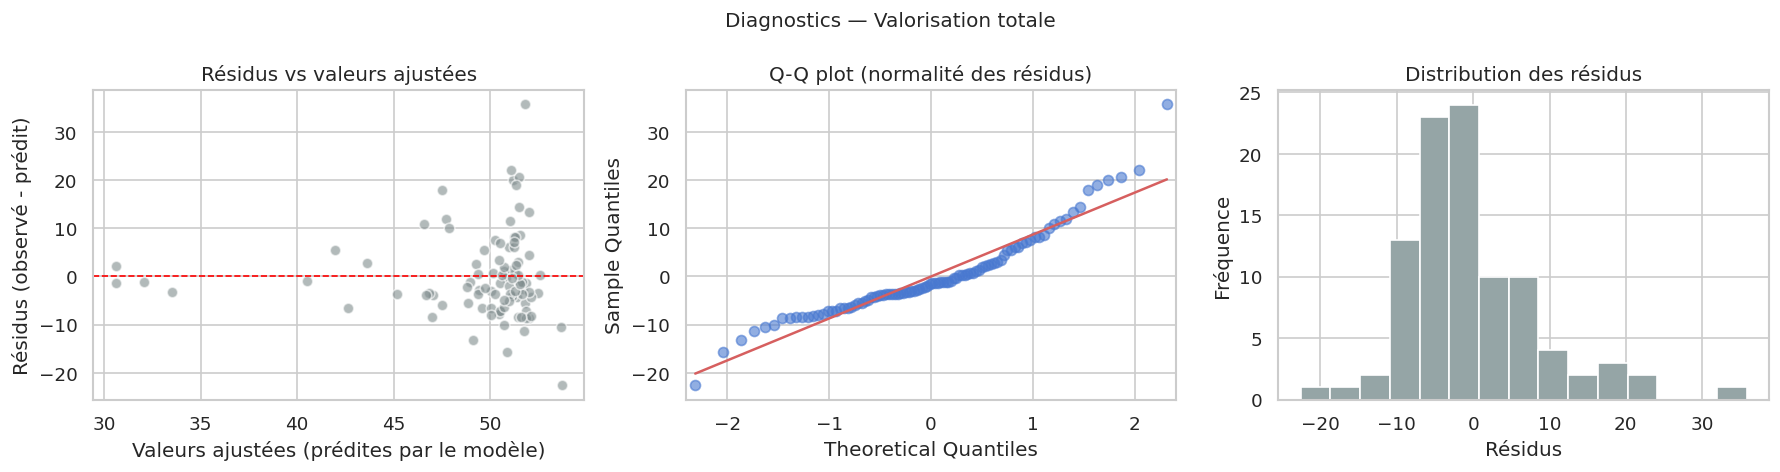

Shapiro-Wilk : W = 0.9225, p = 0.0000
→ Résidus non normaux (p < 0.05) — interpréter les IC avec prudence


In [58]:
# Diagnostics — valorisation totale
diagnostics_ols(mod3_tot, "Valorisation totale")


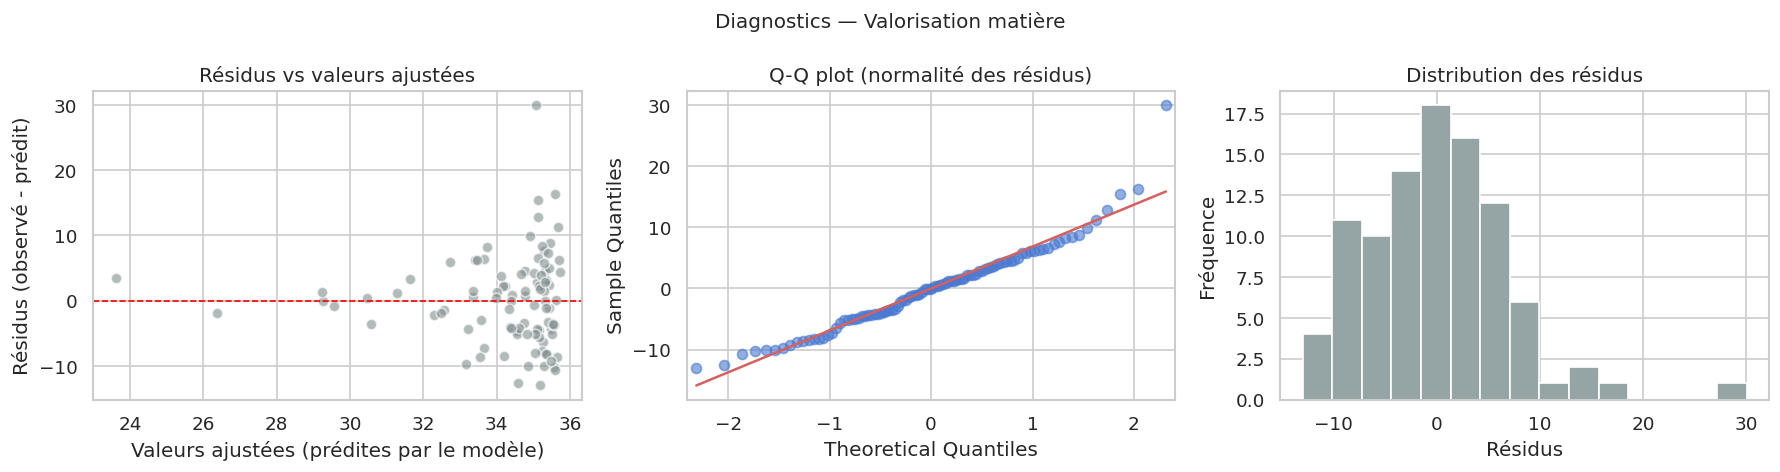

Shapiro-Wilk : W = 0.9522, p = 0.0015
→ Résidus non normaux (p < 0.05) — interpréter les IC avec prudence


In [59]:
#  Diagnostics — valorisation matière 
diagnostics_ols(mod3_mat, "Valorisation matière")


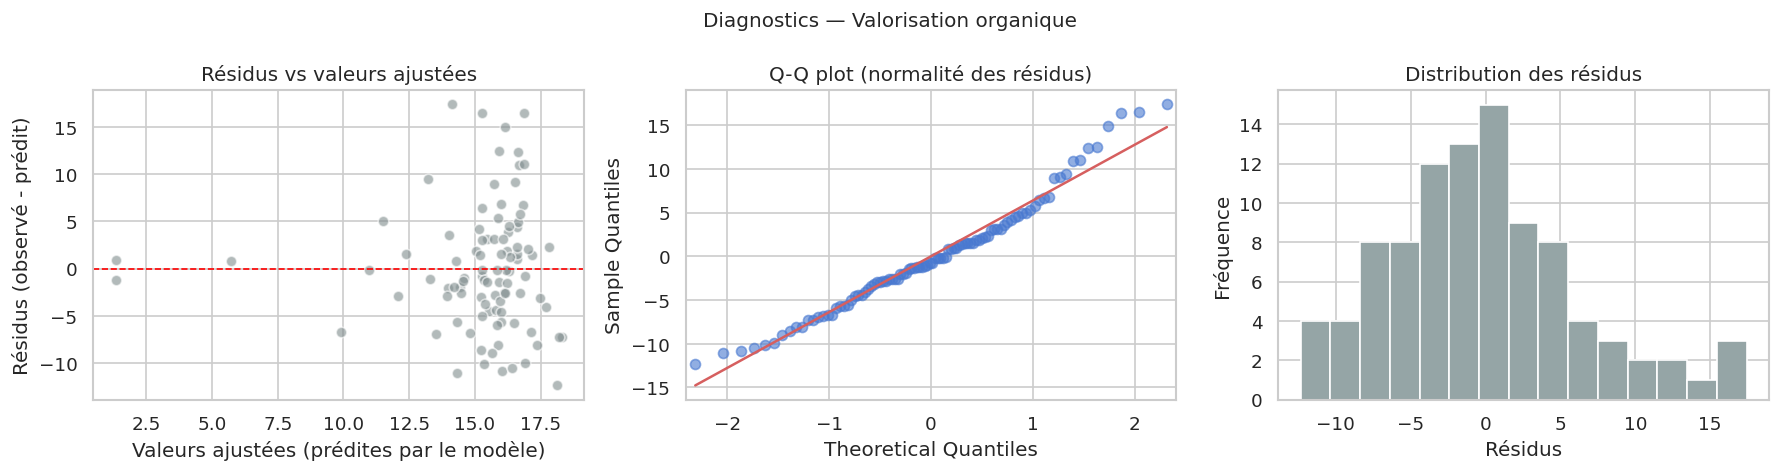

Shapiro-Wilk : W = 0.9686, p = 0.0211
→ Résidus non normaux (p < 0.05) — interpréter les IC avec prudence


In [60]:
#  Diagnostics — valorisation organique 
diagnostics_ols(mod3_org, "Valorisation organique")


**Lecture des diagnostics :**
Les résidus ne sont pas parfaitement normaux — Shapiro-Wilk le confirme (W = 0.9225, p < 0.001). Sur le Q-Q plot, les queues s'écartent de la diagonale, tirées par quelques départements atypiques comme la Vendée ou la Saône-et-Loire. On voit aussi une légère hétéroscédasticité sur le graphique résidus vs valeurs ajustées.

En pratique ça veut dire que les p-values sont à prendre avec prudence.
Une transformation log pourrait être pertinente, mais nous n'avons pas eu le temps de le vérifier.

## 5. Conclusion générale

Cette étude avait pour objectif d'identifier les facteurs territoriaux et socio-économiques associés à la valorisation des déchets ménagers à l'échelle départementale en France.

La ruralité est bien associée à de meilleures performances de valorisation, mais c'est surtout le compostage qui porte cette relation — le recyclage, lui, semble dépendre d'autre chose (infrastructures, politiques locales) que nos données ne capturent pas vraiment.

Le résultat qui semble le plus surprenant : le niveau de vie ne joue pas. On aurait pu penser que les départements riches investissent plus dans les filières de tri, mais ce n'est pas ce qu'on observe. À l'échelle départementale du moins.

Ce qui reste ouvert : notre indicateur de ruralité compte les communes, pas les habitants — Paris pèse autant qu'un village de 200 personnes dans le calcul. C'est une vraie limite. Et avec une seule année de données, on ne peut pas distinguer un effet structurel d'une fluctuation ponctuelle.

Une suite logique serait d'intégrer la densité de déchèteries ou la part de logements individuels avec jardin — des variables qui pourraient expliquer pourquoi deux départements ruraux similaires ont des taux de valorisation aussi différents. Ou même encore s'interesser aux investissements des dépenses publiques en faveur de l'environnement.
